<a href="https://colab.research.google.com/github/Ryuta-Y/cv-practice/blob/main/01_cnn_cifar10_colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
import importlib.util
import json
import os
import random
import subprocess
import sys
import urllib.request
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import torch


def in_colab() -> bool:
    try:
        import google.colab

        return True
    except ImportError:
        return False


def ensure_packages(packages: dict[str, str]) -> None:
    missing = [spec for mod, spec in packages.items() if importlib.util.find_spec(mod) is None]
    if not missing:
        return

    print("不足パッケージをインストールします:")
    for pkg in missing:
        print(" -", pkg)
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", *missing])


def seed_everything(seed: int = 42) -> None:
    """乱数シード固定"""
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)


def get_device() -> torch.device:
    if torch.cuda.is_available():
        return torch.device("cuda")
    return torch.device("cpu")


def print_runtime_info() -> None:
    device = get_device()
    print(f"実行デバイス: {device}")
    if device.type == "cuda":
        print("GPU :", torch.cuda.get_device_name(0))
        print("CUDA version:", torch.version.cuda)


def get_output_dir(name: str, prefer_drive: bool = False) -> Path:
    if prefer_drive and in_colab() and Path("/content/drive/MyDrive").exists():
        root = Path("/content/drive/MyDrive/learning_guide_outputs")
    else:
        root = Path("/content/learning_guide_outputs") if in_colab() else Path("learning_guide_outputs")
    output_dir = root / name
    output_dir.mkdir(parents=True, exist_ok=True)
    print(f"出力先ディレクトリ: {output_dir}")
    return output_dir


def download_file(url: str, output_path: Path) -> Path:
    output_path.parent.mkdir(parents=True, exist_ok=True)
    if output_path.exists():
        print(f"既に存在するため再利用します: {output_path}")
        return output_path

    print(f"ダウンロード中: {url}")
    urllib.request.urlretrieve(url, output_path)
    return output_path


def maybe_mount_drive(do_mount: bool = False) -> None:
    if not do_mount or not in_colab():
        return

    from google.colab import drive  # type: ignore

    drive.mount("/content/drive")


def maybe_upload_files() -> list[Path]:
    if not in_colab():
        return []

    from google.colab import files  # type: ignore

    uploaded = files.upload()
    return [Path(name) for name in uploaded.keys()]


def show_image_grid(
    images: list[np.ndarray],
    titles: list[str] | None = None,
    cols: int = 4,
    figsize=(14, 8),
    output_path: Path | None = None,
) -> None:
    """画像を格子状に並べて表示し、必要なら画像ファイルとして保存する。"""
    if not images:
        return

    rows = int(np.ceil(len(images) / cols))
    plt.figure(figsize=figsize)
    for index, image in enumerate(images, start=1):
        plt.subplot(rows, cols, index)
        plt.imshow(image)
        plt.axis("off")
        if titles and index - 1 < len(titles):
            plt.title(titles[index - 1], fontsize=10)
    plt.tight_layout()
    if output_path is not None:
        output_path.parent.mkdir(parents=True, exist_ok=True)
        plt.savefig(output_path, dpi=200, bbox_inches="tight")
        print(f"画像グリッドを保存しました: {output_path}")
    plt.show()


def plot_training_curves(
    train_losses: list[float],
    val_losses: list[float],
    train_accs: list[float],
    val_accs: list[float],
    output_path: Path | None = None,
) -> None:
    """学習曲線を 2 枚並べて表示・保存する。"""
    plt.figure(figsize=(12, 4))

    plt.subplot(1, 2, 1)
    plt.plot(train_losses, label="train loss")
    plt.plot(val_losses, label="val loss")
    plt.xlabel("epoch")
    plt.ylabel("loss")
    plt.title("Loss Curve")
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(train_accs, label="train acc")
    plt.plot(val_accs, label="val acc")
    plt.xlabel("epoch")
    plt.ylabel("accuracy")
    plt.title("Accuracy Curve")
    plt.legend()

    plt.tight_layout()
    if output_path is not None:
        plt.savefig(output_path, dpi=200, bbox_inches="tight")
        print(f"学習曲線を保存しました: {output_path}")
    plt.show()


def plot_grouped_bar(
    labels: list[str],
    series: dict[str, list[float]],
    title: str,
    ylabel: str,
    output_path: Path | None = None,
) -> None:
    """複数手法の比較を棒グラフで表示する。"""
    if not labels or not series:
        return

    x = np.arange(len(labels))
    width = 0.8 / max(len(series), 1)

    plt.figure(figsize=(max(8, 1.8 * len(labels)), 5))
    for index, (name, values) in enumerate(series.items()):
        offset = (index - (len(series) - 1) / 2) * width
        plt.bar(x + offset, values, width=width, label=name)

    plt.xticks(x, labels, rotation=15)
    plt.ylabel(ylabel)
    plt.title(title)
    plt.legend()
    plt.tight_layout()
    if output_path is not None:
        plt.savefig(output_path, dpi=200, bbox_inches="tight")
        print(f"比較グラフを保存しました: {output_path}")
    plt.show()


def denormalize_image(image_tensor: torch.Tensor, mean: tuple[float, ...], std: tuple[float, ...]) -> np.ndarray:
    """正規化済みテンソルを可視化しやすい画像へ戻す。"""
    image = image_tensor.detach().cpu().clone()
    for channel, m, s in zip(image, mean, std):
        channel.mul_(s).add_(m)
    image = image.clamp(0, 1)
    return image.permute(1, 2, 0).numpy()


def save_text(text: str, output_path: Path) -> None:
    """メモや結果要約を保存する。"""
    output_path.parent.mkdir(parents=True, exist_ok=True)
    output_path.write_text(text, encoding="utf-8")
    print(f"テキストを保存しました: {output_path}")


def save_json(data: dict, output_path: Path) -> None:
    """実験設定や評価指標を JSON で保存する。"""
    output_path.parent.mkdir(parents=True, exist_ok=True)
    output_path.write_text(json.dumps(data, ensure_ascii=False, indent=2), encoding="utf-8")
    print(f"JSON を保存しました: {output_path}")


def count_parameters(model: torch.nn.Module, trainable_only: bool = False) -> int:
    """モデルのパラメータ数を数える。"""
    if trainable_only:
        return sum(parameter.numel() for parameter in model.parameters() if parameter.requires_grad)
    return sum(parameter.numel() for parameter in model.parameters())


def format_seconds(seconds: float) -> str:
    """秒数を読みやすい文字列へ変換する。"""
    minutes, sec = divmod(seconds, 60)
    hours, minutes = divmod(minutes, 60)
    if hours >= 1:
        return f"{int(hours)}h {int(minutes)}m {sec:.1f}s"
    if minutes >= 1:
        return f"{int(minutes)}m {sec:.1f}s"
    return f"{seconds:.2f}s"


def sample_video_frames(video_path: Path, num_frames: int, stride: int = 1) -> list[np.ndarray]:
    """
    動画から RGB フレームを等間隔に取り出す。

    stride を大きくすると、より長い時間範囲からフレームを拾える。
    """
    import cv2

    cap = cv2.VideoCapture(str(video_path))
    frames: list[np.ndarray] = []
    while True:
        ok, frame = cap.read()
        if not ok:
            break
        frames.append(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))
    cap.release()

    if not frames:
        raise RuntimeError(f"動画からフレームを読めませんでした: {video_path}")

    candidate_frames = frames[:: max(1, stride)]
    if len(candidate_frames) == 1:
        return [candidate_frames[0].copy() for _ in range(num_frames)]

    indices = np.linspace(0, len(candidate_frames) - 1, num=num_frames, dtype=int)
    sampled = [candidate_frames[index].copy() for index in indices]
    while len(sampled) < num_frames:
        sampled.append(sampled[-1].copy())
    return sampled


Mounted at /content/drive
出力先ディレクトリ: /content/drive/MyDrive/learning_guide_outputs/01_cnn_cifar10
実行デバイス: cuda
GPU : NVIDIA H100 80GB HBM3
CUDA version: 12.8


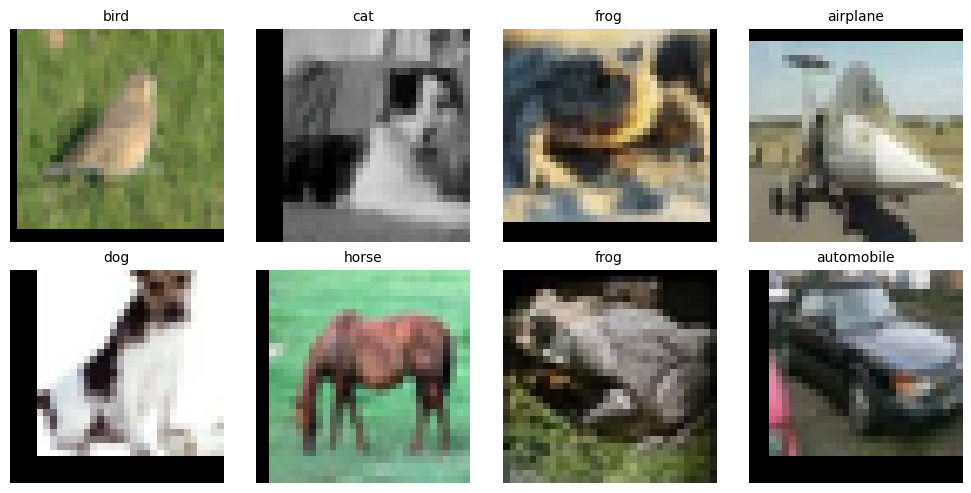

linear_classifier_e5 parameters: total=30,730, trainable=30,730
[linear_classifier_e5][Epoch 1/5] train_loss=2.0963 train_acc=0.2716 val_loss=2.0588 val_acc=0.2778 epoch_time=3.62s
[linear_classifier_e5][Epoch 2/5] train_loss=2.0425 train_acc=0.2918 val_loss=2.0736 val_acc=0.2742 epoch_time=3.02s
[linear_classifier_e5][Epoch 3/5] train_loss=2.0584 train_acc=0.2934 val_loss=2.1013 val_acc=0.2702 epoch_time=3.08s
[linear_classifier_e5][Epoch 4/5] train_loss=2.0404 train_acc=0.2954 val_loss=2.0427 val_acc=0.2765 epoch_time=3.11s
[linear_classifier_e5][Epoch 5/5] train_loss=2.0409 train_acc=0.2954 val_loss=2.0689 val_acc=0.2895 epoch_time=3.10s
学習曲線を保存しました: /content/drive/MyDrive/learning_guide_outputs/01_cnn_cifar10/linear_classifier_e5_training_curves.png


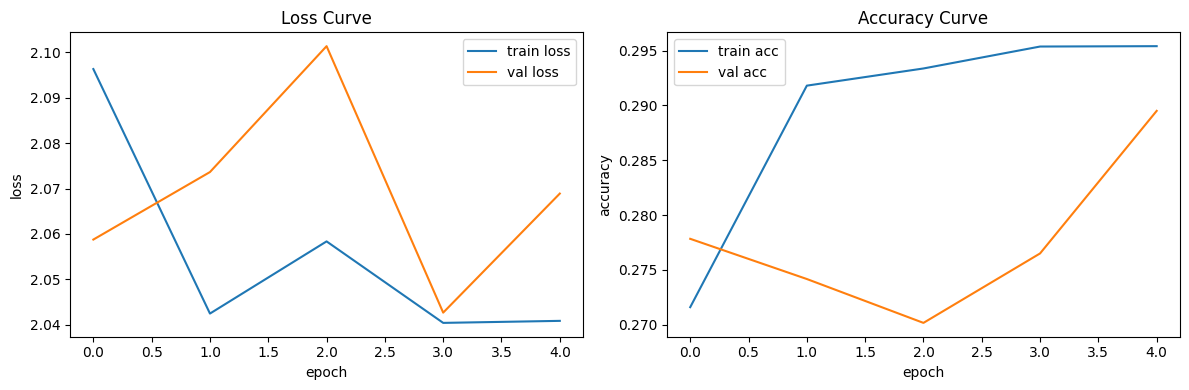

linear_classifier_e5 の最終 test loss: 1.9381
linear_classifier_e5 の最終 test accuracy: 0.3324
linear_classifier_e5 の test 評価時間: 0.62s
重みを保存しました: /content/drive/MyDrive/learning_guide_outputs/01_cnn_cifar10/linear_classifier_e5.pt
linear_classifier_e10 parameters: total=30,730, trainable=30,730
[linear_classifier_e10][Epoch 1/10] train_loss=2.0945 train_acc=0.2715 val_loss=2.1167 val_acc=0.2667 epoch_time=3.13s
[linear_classifier_e10][Epoch 2/10] train_loss=2.0386 train_acc=0.2956 val_loss=2.0542 val_acc=0.2858 epoch_time=3.17s
[linear_classifier_e10][Epoch 3/10] train_loss=2.0476 train_acc=0.2968 val_loss=2.0132 val_acc=0.2963 epoch_time=3.03s
[linear_classifier_e10][Epoch 4/10] train_loss=2.0308 train_acc=0.3021 val_loss=2.0931 val_acc=0.2803 epoch_time=3.09s
[linear_classifier_e10][Epoch 5/10] train_loss=2.0372 train_acc=0.2985 val_loss=2.0976 val_acc=0.2848 epoch_time=3.07s
[linear_classifier_e10][Epoch 6/10] train_loss=2.0417 train_acc=0.3009 val_loss=2.0879 val_acc=0.2803 epoch_time=3

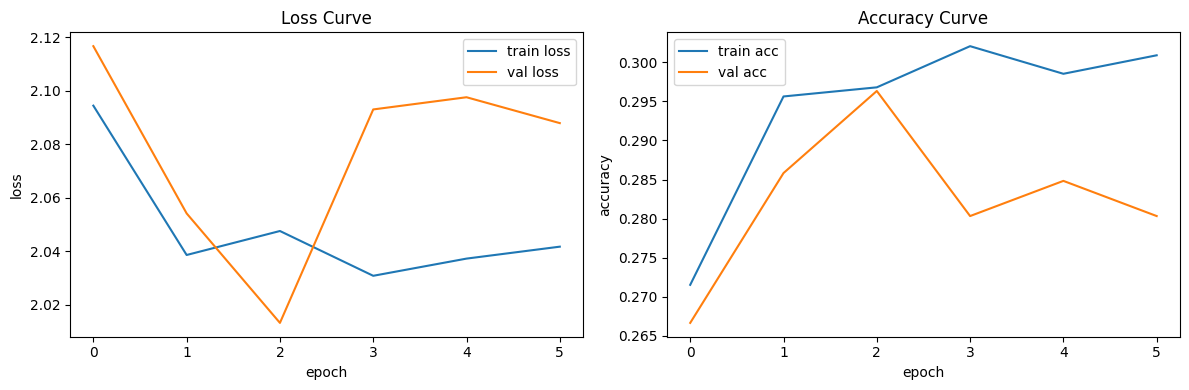

linear_classifier_e10 の最終 test loss: 1.9350
linear_classifier_e10 の最終 test accuracy: 0.3410
linear_classifier_e10 の test 評価時間: 0.57s
重みを保存しました: /content/drive/MyDrive/learning_guide_outputs/01_cnn_cifar10/linear_classifier_e10.pt
small_cnn_e5 parameters: total=391,946, trainable=391,946
[small_cnn_e5][Epoch 1/5] train_loss=1.5299 train_acc=0.4425 val_loss=1.3813 val_acc=0.4988 epoch_time=4.10s
[small_cnn_e5][Epoch 2/5] train_loss=1.1962 train_acc=0.5713 val_loss=1.4354 val_acc=0.5037 epoch_time=3.11s
[small_cnn_e5][Epoch 3/5] train_loss=1.0669 train_acc=0.6195 val_loss=1.2210 val_acc=0.5453 epoch_time=3.11s
[small_cnn_e5][Epoch 4/5] train_loss=0.9825 train_acc=0.6538 val_loss=1.3983 val_acc=0.5557 epoch_time=3.04s
[small_cnn_e5][Epoch 5/5] train_loss=0.9228 train_acc=0.6755 val_loss=0.9731 val_acc=0.6472 epoch_time=3.02s
学習曲線を保存しました: /content/drive/MyDrive/learning_guide_outputs/01_cnn_cifar10/small_cnn_e5_training_curves.png


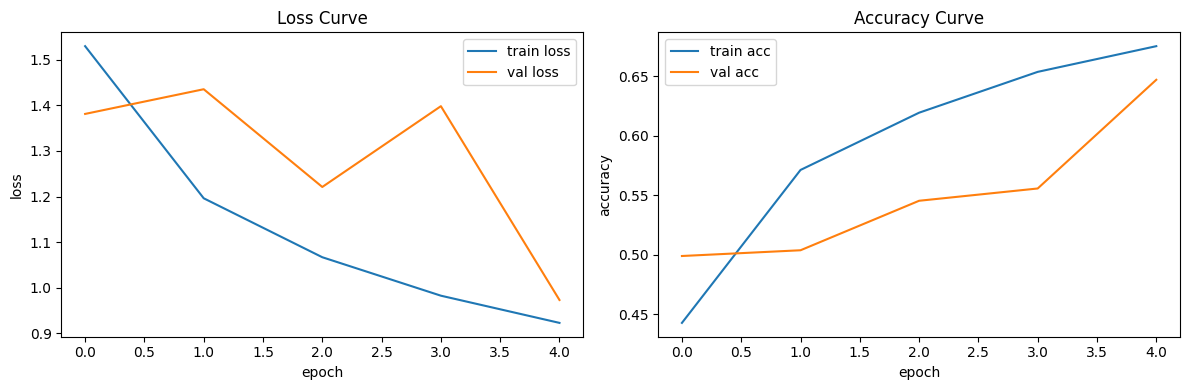

small_cnn_e5 の最終 test loss: 0.9981
small_cnn_e5 の最終 test accuracy: 0.6502
small_cnn_e5 の test 評価時間: 0.61s
重みを保存しました: /content/drive/MyDrive/learning_guide_outputs/01_cnn_cifar10/small_cnn_e5.pt
small_cnn_e10 parameters: total=391,946, trainable=391,946
[small_cnn_e10][Epoch 1/10] train_loss=1.5268 train_acc=0.4418 val_loss=1.2898 val_acc=0.5312 epoch_time=3.30s
[small_cnn_e10][Epoch 2/10] train_loss=1.2083 train_acc=0.5646 val_loss=1.2428 val_acc=0.5517 epoch_time=3.04s
[small_cnn_e10][Epoch 3/10] train_loss=1.0739 train_acc=0.6175 val_loss=1.0872 val_acc=0.6143 epoch_time=3.05s
[small_cnn_e10][Epoch 4/10] train_loss=0.9911 train_acc=0.6494 val_loss=1.0827 val_acc=0.6132 epoch_time=3.11s
[small_cnn_e10][Epoch 5/10] train_loss=0.9285 train_acc=0.6730 val_loss=1.0804 val_acc=0.6162 epoch_time=3.16s
[small_cnn_e10][Epoch 6/10] train_loss=0.8742 train_acc=0.6941 val_loss=0.9754 val_acc=0.6403 epoch_time=3.13s
[small_cnn_e10][Epoch 7/10] train_loss=0.8299 train_acc=0.7124 val_loss=1.0795 va

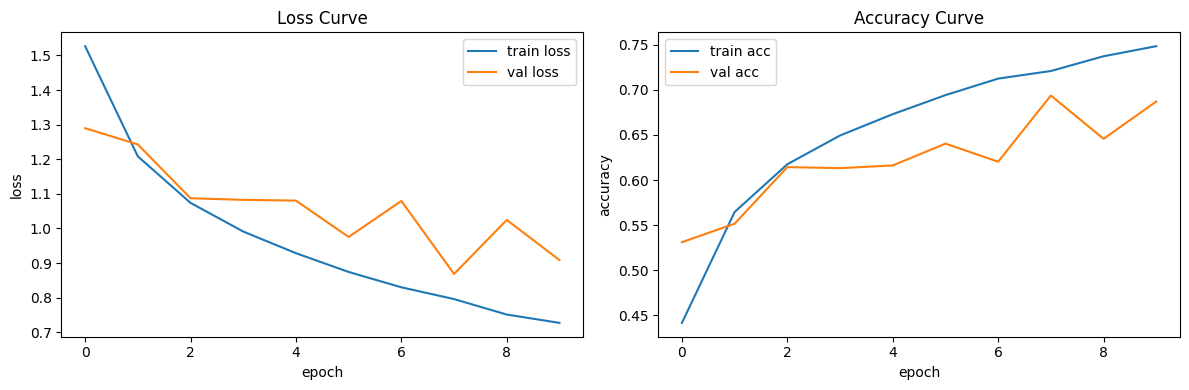

small_cnn_e10 の最終 test loss: 0.8653
small_cnn_e10 の最終 test accuracy: 0.6987
small_cnn_e10 の test 評価時間: 0.61s
重みを保存しました: /content/drive/MyDrive/learning_guide_outputs/01_cnn_cifar10/small_cnn_e10.pt
residual_cnn_e10 parameters: total=696,618, trainable=696,618
[residual_cnn_e10][Epoch 1/10] train_loss=1.5191 train_acc=0.4386 val_loss=1.4561 val_acc=0.4893 epoch_time=3.26s
[residual_cnn_e10][Epoch 2/10] train_loss=1.1153 train_acc=0.5953 val_loss=1.1617 val_acc=0.5873 epoch_time=3.06s
[residual_cnn_e10][Epoch 3/10] train_loss=0.9490 train_acc=0.6600 val_loss=1.1758 val_acc=0.5983 epoch_time=3.08s
[residual_cnn_e10][Epoch 4/10] train_loss=0.8371 train_acc=0.7025 val_loss=1.2666 val_acc=0.5905 epoch_time=3.05s
[residual_cnn_e10][Epoch 5/10] train_loss=0.7486 train_acc=0.7377 val_loss=0.9796 val_acc=0.6642 epoch_time=3.14s
[residual_cnn_e10][Epoch 6/10] train_loss=0.6759 train_acc=0.7639 val_loss=0.7571 val_acc=0.7417 epoch_time=3.09s
[residual_cnn_e10][Epoch 7/10] train_loss=0.6202 train_a

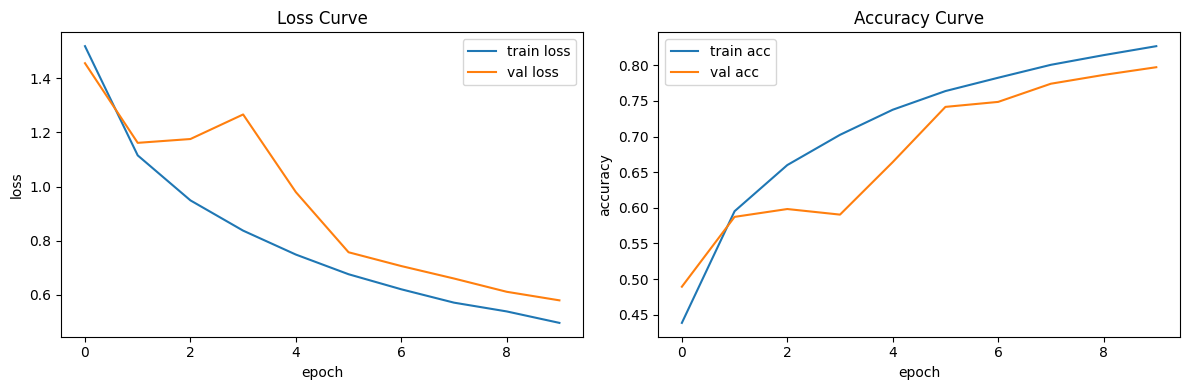

residual_cnn_e10 の最終 test loss: 0.5899
residual_cnn_e10 の最終 test accuracy: 0.8040
residual_cnn_e10 の test 評価時間: 0.62s
重みを保存しました: /content/drive/MyDrive/learning_guide_outputs/01_cnn_cifar10/residual_cnn_e10.pt


/tmp/ipykernel_1904/657630076.py:181: UserWarning: Glyph 12514 (\N{KATAKANA LETTER MO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1904/657630076.py:181: UserWarning: Glyph 12487 (\N{KATAKANA LETTER DE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1904/657630076.py:181: UserWarning: Glyph 12523 (\N{KATAKANA LETTER RU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1904/657630076.py:181: UserWarning: Glyph 31278 (\N{CJK UNIFIED IDEOGRAPH-7A2E}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1904/657630076.py:181: UserWarning: Glyph 21029 (\N{CJK UNIFIED IDEOGRAPH-5225}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1904/657630076.py:181: UserWarning: Glyph 25968 (\N{CJK UNIFIED IDEOGRAPH-6570}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1904/657630076.py:183: UserWarning: Glyph 12514 (\N{KATAKANA LETTER MO}) missing from font(s) DejaVu Sa

比較グラフを保存しました: /content/drive/MyDrive/learning_guide_outputs/01_cnn_cifar10/cnn_vs_linear_accuracy.png


/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 12514 (\N{KATAKANA LETTER MO}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 12487 (\N{KATAKANA LETTER DE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 12523 (\N{KATAKANA LETTER RU}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 31278 (\N{CJK UNIFIED IDEOGRAPH-7A2E}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 21029 (\N{CJK UNIFIED IDEOGRAPH-5225}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, 

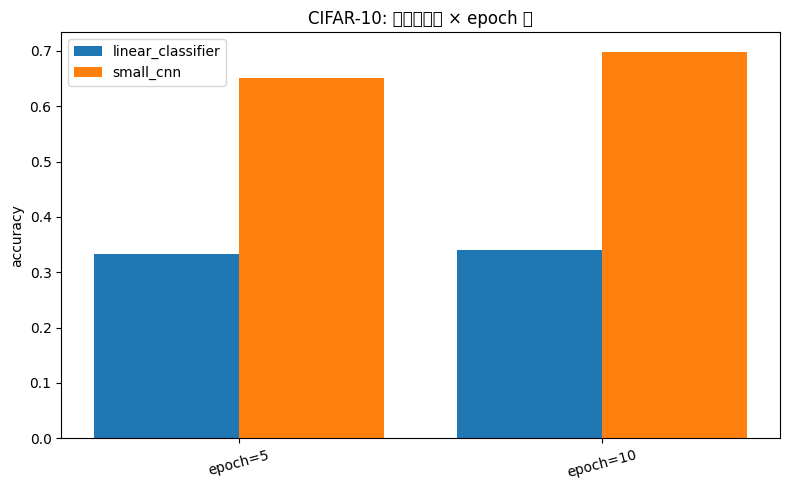

比較グラフを保存しました: /content/drive/MyDrive/learning_guide_outputs/01_cnn_cifar10/cnn_vs_linear_runtime.png


/tmp/ipykernel_1904/657630076.py:181: UserWarning: Glyph 12514 (\N{KATAKANA LETTER MO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1904/657630076.py:181: UserWarning: Glyph 12487 (\N{KATAKANA LETTER DE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1904/657630076.py:181: UserWarning: Glyph 12523 (\N{KATAKANA LETTER RU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1904/657630076.py:181: UserWarning: Glyph 31278 (\N{CJK UNIFIED IDEOGRAPH-7A2E}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1904/657630076.py:181: UserWarning: Glyph 21029 (\N{CJK UNIFIED IDEOGRAPH-5225}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1904/657630076.py:181: UserWarning: Glyph 26178 (\N{CJK UNIFIED IDEOGRAPH-6642}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1904/657630076.py:181: UserWarning: Glyph 38291 (\N{CJK UNIFIED IDEOGRAPH-9593}) missing from font(s) D

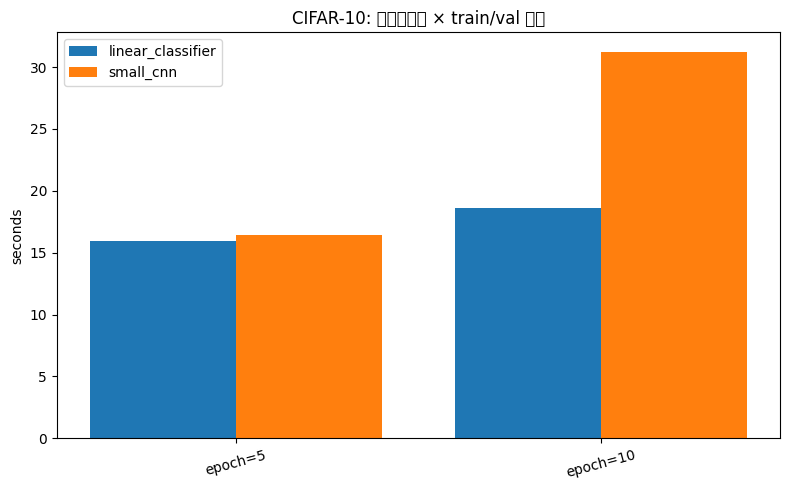

/tmp/ipykernel_1904/657630076.py:181: UserWarning: Glyph 36861 (\N{CJK UNIFIED IDEOGRAPH-8FFD}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1904/657630076.py:181: UserWarning: Glyph 21152 (\N{CJK UNIFIED IDEOGRAPH-52A0}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1904/657630076.py:181: UserWarning: Glyph 27604 (\N{CJK UNIFIED IDEOGRAPH-6BD4}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1904/657630076.py:181: UserWarning: Glyph 36611 (\N{CJK UNIFIED IDEOGRAPH-8F03}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1904/657630076.py:183: UserWarning: Glyph 36861 (\N{CJK UNIFIED IDEOGRAPH-8FFD}) missing from font(s) DejaVu Sans.
  plt.savefig(output_path, dpi=200, bbox_inches="tight")
/tmp/ipykernel_1904/657630076.py:183: UserWarning: Glyph 21152 (\N{CJK UNIFIED IDEOGRAPH-52A0}) missing from font(s) DejaVu Sans.
  plt.savefig(output_path, dpi=200, bbox_inches="tight")
/tmp/ipykernel_1904/65

比較グラフを保存しました: /content/drive/MyDrive/learning_guide_outputs/01_cnn_cifar10/residual_cnn_extra_comparison.png


/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 36861 (\N{CJK UNIFIED IDEOGRAPH-8FFD}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 21152 (\N{CJK UNIFIED IDEOGRAPH-52A0}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 27604 (\N{CJK UNIFIED IDEOGRAPH-6BD4}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 36611 (\N{CJK UNIFIED IDEOGRAPH-8F03}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


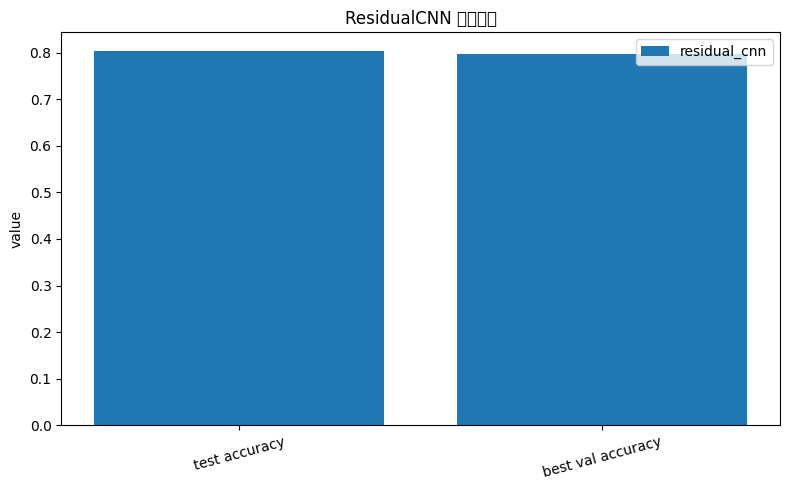

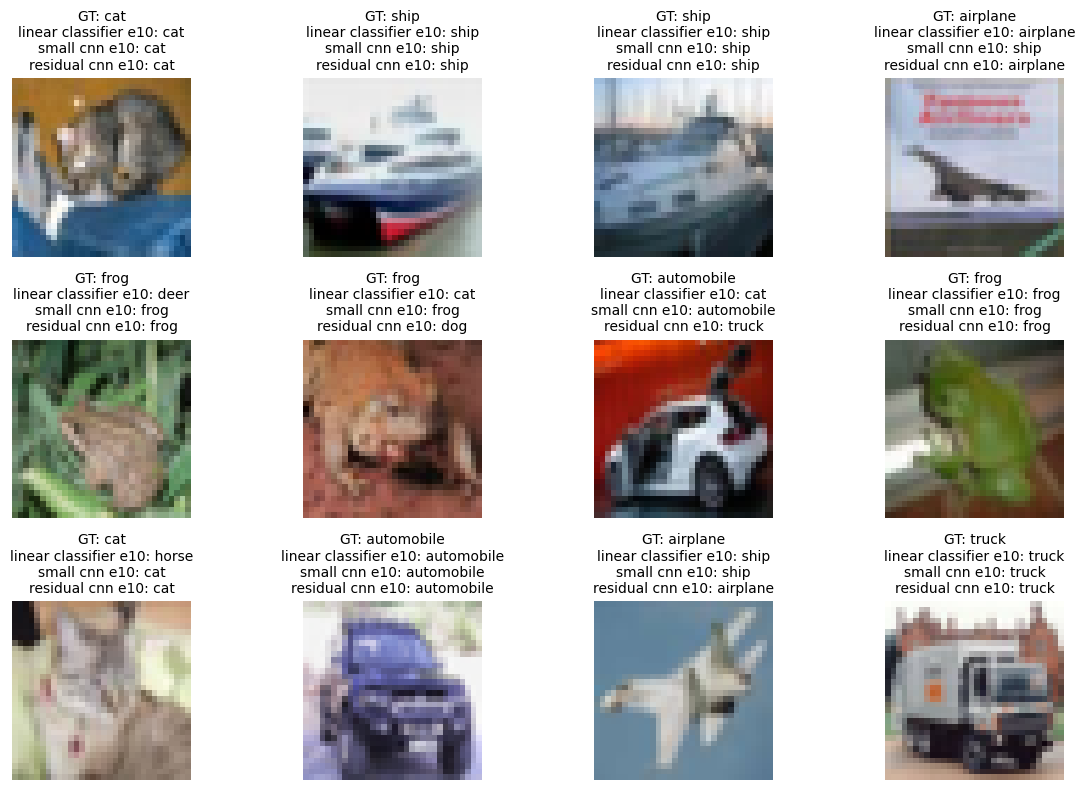

テキストを保存しました: /content/drive/MyDrive/learning_guide_outputs/01_cnn_cifar10/summary.txt
JSON を保存しました: /content/drive/MyDrive/learning_guide_outputs/01_cnn_cifar10/metrics.json


In [4]:
ensure_packages({})

import time
import copy
import matplotlib.pyplot as plt
import torch
from torch import nn
from torch.utils.data import DataLoader, Subset, random_split
from torchvision import datasets, transforms



# 実験設定
SEED = 42
BATCH_SIZE = 128
EPOCHS = 15
EPOCH_OPTIONS = [5, 10]
LEARNING_RATE = 1e-3
TRAIN_SAMPLES = 30000
VAL_SAMPLES = 6000
NUM_WORKERS = 2
IMAGE_SIZE = 32
TRAIN_CROP_PADDING = 4
CNN_CHANNELS = [32, 64, 128, 256]
CNN_POOL_AFTER_BLOCKS = [1, 2]
CNN_DROPOUT = 0.2
CNN_USE_BATCHNORM = True
RUN_RESIDUAL_CNN = True
RESIDUAL_CHANNELS = [32, 64, 128]
RESIDUAL_BLOCKS_PER_STAGE = 2
EARLY_STOPPING_PATIENCE = 3
EARLY_STOPPING_MIN_DELTA = 1e-4
RESTORE_BEST_WEIGHTS = True
SAMPLE_GRID_COUNT = 8
SAMPLE_GRID_COLS = 4
PREDICTION_PREVIEW_COUNT = 12
PREDICTION_GRID_COLS = 4
SAMPLE_GRID_FIGSIZE = (10, 5)
PREDICTION_GRID_FIGSIZE = (12, 8)

MEAN = (0.4914, 0.4822, 0.4465)
STD = (0.2470, 0.2435, 0.2616)


class SmallCNN(nn.Module):
    """CIFAR-10 NN"""

    def __init__(
        self,
        num_classes: int = 10,
        channels: list[int] | tuple[int, ...] = tuple(CNN_CHANNELS),
        pool_after_blocks: list[int] | tuple[int, ...] = tuple(CNN_POOL_AFTER_BLOCKS),
        dropout: float = CNN_DROPOUT,
        use_batchnorm: bool = CNN_USE_BATCHNORM,
    ) -> None:
        super().__init__()
        feature_layers = []
        in_channels = 3
        pool_after_blocks = set(pool_after_blocks)
        for block_index, out_channels in enumerate(channels):
            feature_layers.append(nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1))
            if use_batchnorm:
                feature_layers.append(nn.BatchNorm2d(out_channels))
            feature_layers.append(nn.ReLU(inplace=True))
            if block_index in pool_after_blocks:
                feature_layers.append(nn.MaxPool2d(2))
            in_channels = out_channels
        feature_layers.append(nn.AdaptiveAvgPool2d((1, 1)))
        self.features = nn.Sequential(*feature_layers)
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Dropout(dropout),
            nn.Linear(in_channels, num_classes),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.classifier(self.features(x))


class LinearClassifier(nn.Module):

    def __init__(self, num_classes: int = 10, image_size: int = IMAGE_SIZE) -> None:
        super().__init__()
        self.classifier = nn.Linear(3 * image_size * image_size, num_classes)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.classifier(x.flatten(start_dim=1))


class ResidualBlock(nn.Module):
    """ResNet 風 skip connection"""

    def __init__(self, in_channels: int, out_channels: int, stride: int = 1) -> None:
        super().__init__()
        self.conv1 = nn.Conv2d(in_channels, out_channels, kernel_size=3, stride=stride, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(out_channels)
        self.relu = nn.ReLU(inplace=True)
        self.conv2 = nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1, bias=False)
        self.bn2 = nn.BatchNorm2d(out_channels)
        if stride != 1 or in_channels != out_channels:
            self.shortcut = nn.Sequential(
                nn.Conv2d(in_channels, out_channels, kernel_size=1, stride=stride, bias=False),
                nn.BatchNorm2d(out_channels),
            )
        else:
            self.shortcut = nn.Identity()

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        identity = self.shortcut(x)
        out = self.relu(self.bn1(self.conv1(x)))
        out = self.bn2(self.conv2(out))
        out = self.relu(out + identity)
        return out


class ResidualCNN(nn.Module):
    """小規模データで試しやすい ResNet 風モデル。"""

    def __init__(
        self,
        num_classes: int = 10,
        channels: list[int] | tuple[int, ...] = tuple(RESIDUAL_CHANNELS),
        blocks_per_stage: int = RESIDUAL_BLOCKS_PER_STAGE,
    ) -> None:
        super().__init__()
        stem_channels = channels[0]
        self.stem = nn.Sequential(
            nn.Conv2d(3, stem_channels, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(stem_channels),
            nn.ReLU(inplace=True),
        )

        stages = []
        in_channels = stem_channels
        for stage_index, out_channels in enumerate(channels):
            stride = 1 if stage_index == 0 else 2
            blocks = [ResidualBlock(in_channels, out_channels, stride=stride)]
            for _ in range(blocks_per_stage - 1):
                blocks.append(ResidualBlock(out_channels, out_channels, stride=1))
            stages.append(nn.Sequential(*blocks))
            in_channels = out_channels
        self.stages = nn.Sequential(*stages)
        self.pool = nn.AdaptiveAvgPool2d((1, 1))
        self.classifier = nn.Linear(in_channels, num_classes)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = self.stem(x)
        x = self.stages(x)
        x = self.pool(x)
        x = torch.flatten(x, 1)
        return self.classifier(x)


def run_epoch(model, loader, criterion, optimizer, device):

    is_train = optimizer is not None
    model.train(is_train)
    total_loss = 0.0
    total_correct = 0
    total_count = 0
    start_time = time.perf_counter()

    scaler = torch.amp.GradScaler("cuda") if is_train and device.type == "cuda" else None

    for images, labels in loader:
        images = images.to(device)
        labels = labels.to(device)

        if is_train:
            optimizer.zero_grad(set_to_none=True)

        with torch.set_grad_enabled(is_train):
            with torch.amp.autocast(device_type=device.type, enabled=device.type == "cuda"):
                logits = model(images)
                loss = criterion(logits, labels)

            if is_train:
                if scaler is not None:
                    scaler.scale(loss).backward()
                    scaler.step(optimizer)
                    scaler.update()
                else:
                    loss.backward()
                    optimizer.step()

        # classification では最大 logit の index を予測クラスとみなす。
        preds = logits.argmax(dim=1)
        total_loss += loss.item() * labels.size(0)
        total_correct += (preds == labels).sum().item()
        total_count += labels.size(0)

    elapsed_sec = time.perf_counter() - start_time
    return total_loss / total_count, total_correct / total_count, elapsed_sec


def train_model(model_name, model, train_loader, val_loader, test_loader, classes, test_dataset, device, output_dir, num_epochs):

    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)
    train_losses, val_losses, train_accs, val_accs = [], [], [], []
    epoch_times = []
    total_parameters = count_parameters(model)
    trainable_parameters = count_parameters(model, trainable_only=True)
    best_val_loss = float("inf")
    best_val_acc = 0.0
    best_epoch = 0
    early_stop_counter = 0
    early_stopped = False
    best_state_dict = copy.deepcopy(model.state_dict())

    print(
        f"{model_name} parameters: total={total_parameters:,}, "
        f"trainable={trainable_parameters:,}"
    )

    for epoch in range(num_epochs):

        train_loss, train_acc, train_epoch_sec = run_epoch(model, train_loader, criterion, optimizer, device)
        val_loss, val_acc, val_epoch_sec = run_epoch(model, val_loader, criterion, optimizer=None, device=device)

        train_losses.append(train_loss)
        val_losses.append(val_loss)
        train_accs.append(train_acc)
        val_accs.append(val_acc)
        epoch_times.append(
            {
                "epoch": epoch + 1,
                "train_seconds": train_epoch_sec,
                "val_seconds": val_epoch_sec,
                "total_seconds": train_epoch_sec + val_epoch_sec,
            }
        )

        print(
            f"[{model_name}][Epoch {epoch + 1}/{num_epochs}] "
            f"train_loss={train_loss:.4f} train_acc={train_acc:.4f} "
            f"val_loss={val_loss:.4f} val_acc={val_acc:.4f} "
            f"epoch_time={format_seconds(train_epoch_sec + val_epoch_sec)}"
        )

        if val_loss < best_val_loss - EARLY_STOPPING_MIN_DELTA:
            best_val_loss = val_loss
            best_val_acc = val_acc
            best_epoch = epoch + 1
            early_stop_counter = 0
            best_state_dict = copy.deepcopy(model.state_dict())
        else:
            early_stop_counter += 1

        if EARLY_STOPPING_PATIENCE is not None and early_stop_counter >= EARLY_STOPPING_PATIENCE:
            early_stopped = True
            print(
                f"{model_name}: val loss が改善しないため epoch {epoch + 1} で early stopping します。"
            )
            break

    if RESTORE_BEST_WEIGHTS:
        model.load_state_dict(best_state_dict)

    plot_training_curves(
        train_losses,
        val_losses,
        train_accs,
        val_accs,
        output_path=output_dir / f"{model_name}_training_curves.png",
    )


    test_loss, test_acc, test_sec = run_epoch(model, test_loader, criterion, optimizer=None, device=device)
    print(f"{model_name} の最終 test loss: {test_loss:.4f}")
    print(f"{model_name} の最終 test accuracy: {test_acc:.4f}")
    print(f"{model_name} の test 評価時間: {format_seconds(test_sec)}")

    predictions = []
    model.eval()
    with torch.no_grad():

        for i in range(PREDICTION_PREVIEW_COUNT):
            image, label = test_dataset[i]
            logits = model(image.unsqueeze(0).to(device))
            pred = logits.argmax(dim=1).item()
            predictions.append((image, label, pred))

    torch.save(model.state_dict(), output_dir / f"{model_name}.pt")
    print(f"重みを保存しました: {output_dir / f'{model_name}.pt'}")

    return {
        "name": model_name,
        "num_epochs": num_epochs,
        "test_loss": test_loss,
        "test_acc": test_acc,
        "test_seconds": test_sec,
        "total_parameters": total_parameters,
        "trainable_parameters": trainable_parameters,
        "epoch_times": epoch_times,
        "train_losses": train_losses,
        "val_losses": val_losses,
        "train_accs": train_accs,
        "val_accs": val_accs,
        "best_val_loss": best_val_loss,
        "best_val_acc": best_val_acc,
        "best_epoch": best_epoch,
        "early_stopped": early_stopped,
        "predictions": predictions,
    }


def main() -> None:
    overall_start = time.perf_counter()
    seed_everything(SEED)
    device = get_device()
    maybe_mount_drive(do_mount=True)
    output_dir = get_output_dir("01_cnn_cifar10", prefer_drive=True)
    print_runtime_info()

    train_transform = transforms.Compose(
        [
            transforms.RandomCrop(32, padding=TRAIN_CROP_PADDING),
            transforms.RandomHorizontalFlip(),
            transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
            transforms.ToTensor(),
            transforms.Normalize(MEAN, STD),
        ]
    )
    eval_transform = transforms.Compose(
        [
            transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
            transforms.ToTensor(),
            transforms.Normalize(MEAN, STD),
        ]
    )

    train_dataset_full = datasets.CIFAR10(root=output_dir / "data", train=True, download=True, transform=train_transform)
    test_dataset = datasets.CIFAR10(root=output_dir / "data", train=False, download=True, transform=eval_transform)

    train_subset = Subset(train_dataset_full, list(range(TRAIN_SAMPLES + VAL_SAMPLES)))
    train_dataset, val_dataset = random_split(
        train_subset,
        [TRAIN_SAMPLES, VAL_SAMPLES],
        generator=torch.Generator().manual_seed(SEED),
    )

    train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS)
    val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)
    test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)

    # 学習前に入力画像を可視化しておくと、
    # 前処理が壊れていないか、クラスがそれらしく並んでいるかを確認できる。
    sample_images = []
    sample_titles = []
    classes = train_dataset_full.classes
    for i in range(SAMPLE_GRID_COUNT):
        image, label = train_dataset[i]
        sample_images.append(denormalize_image(image, MEAN, STD))
        sample_titles.append(classes[label])
    show_image_grid(sample_images, sample_titles, cols=SAMPLE_GRID_COLS, figsize=SAMPLE_GRID_FIGSIZE)

    results = []
    # まずは「モデルの違い」に加えて「epoch 数の違い」も見る。
    for num_epochs in EPOCH_OPTIONS:
        results.append(
            train_model(
                f"linear_classifier_e{num_epochs}",
                LinearClassifier(num_classes=10, image_size=IMAGE_SIZE).to(device),
                train_loader,
                val_loader,
                test_loader,
                classes,
                test_dataset,
                device,
                output_dir,
                num_epochs=num_epochs,
            )
        )
    for num_epochs in EPOCH_OPTIONS:
        results.append(
            train_model(
                f"small_cnn_e{num_epochs}",
                SmallCNN(
                    num_classes=10,
                    channels=CNN_CHANNELS,
                    pool_after_blocks=CNN_POOL_AFTER_BLOCKS,
                    dropout=CNN_DROPOUT,
                    use_batchnorm=CNN_USE_BATCHNORM,
                ).to(device),
                train_loader,
                val_loader,
                test_loader,
                classes,
                test_dataset,
                device,
                output_dir,
                num_epochs=num_epochs,
            )
        )
    if RUN_RESIDUAL_CNN:
        results.append(
            train_model(
                f"residual_cnn_e{max(EPOCH_OPTIONS)}",
                ResidualCNN(
                    num_classes=10,
                    channels=RESIDUAL_CHANNELS,
                    blocks_per_stage=RESIDUAL_BLOCKS_PER_STAGE,
                ).to(device),
                train_loader,
                val_loader,
                test_loader,
                classes,
                test_dataset,
                device,
                output_dir,
                num_epochs=max(EPOCH_OPTIONS),
            )
        )

    epoch_labels = [f"epoch={num_epochs}" for num_epochs in EPOCH_OPTIONS]
    accuracy_series = {
        "linear_classifier": [
            next(result["test_acc"] for result in results if result["name"] == f"linear_classifier_e{num_epochs}")
            for num_epochs in EPOCH_OPTIONS
        ],
        "small_cnn": [
            next(result["test_acc"] for result in results if result["name"] == f"small_cnn_e{num_epochs}")
            for num_epochs in EPOCH_OPTIONS
        ],
    }
    runtime_series = {
        "linear_classifier": [
            sum(
                item["total_seconds"]
                for item in next(
                    result["epoch_times"] for result in results if result["name"] == f"linear_classifier_e{num_epochs}"
                )
            )
            for num_epochs in EPOCH_OPTIONS
        ],
        "small_cnn": [
            sum(
                item["total_seconds"]
                for item in next(
                    result["epoch_times"] for result in results if result["name"] == f"small_cnn_e{num_epochs}"
                )
            )
            for num_epochs in EPOCH_OPTIONS
        ],
    }

    # 比較実験の主結果。ここで 2x2 の違いを見る。
    plot_grouped_bar(
        labels=epoch_labels,
        series=accuracy_series,
        title="CIFAR-10: モデル種別 × epoch 数",
        ylabel="accuracy",
        output_path=output_dir / "cnn_vs_linear_accuracy.png",
    )
    plot_grouped_bar(
        labels=epoch_labels,
        series=runtime_series,
        title="CIFAR-10: モデル種別 × train/val 時間",
        ylabel="seconds",
        output_path=output_dir / "cnn_vs_linear_runtime.png",
    )
    if RUN_RESIDUAL_CNN:
        residual_result = next(result for result in results if result["name"] == f"residual_cnn_e{max(EPOCH_OPTIONS)}")
        plot_grouped_bar(
            labels=["test accuracy", "best val accuracy"],
            series={
                "residual_cnn": [residual_result["test_acc"], residual_result["best_val_acc"]],
            },
            title="ResidualCNN 追加比較",
            ylabel="value",
            output_path=output_dir / "residual_cnn_extra_comparison.png",
        )

    preview_images = []
    preview_titles = []
    preview_results = [
        next(result for result in results if result["name"] == f"linear_classifier_e{max(EPOCH_OPTIONS)}"),
        next(result for result in results if result["name"] == f"small_cnn_e{max(EPOCH_OPTIONS)}"),
    ]
    if RUN_RESIDUAL_CNN:
        preview_results.append(next(result for result in results if result["name"] == f"residual_cnn_e{max(EPOCH_OPTIONS)}"))
    for sample_index in range(PREDICTION_PREVIEW_COUNT):
        image = preview_results[0]["predictions"][sample_index][0]
        label = preview_results[0]["predictions"][sample_index][1]
        preview_images.append(denormalize_image(image, MEAN, STD))
        title_lines = [f"GT: {classes[label]}"]
        for result in preview_results:
            pred = result["predictions"][sample_index][2]
            short_name = result["name"].replace("_", " ")
            title_lines.append(f"{short_name}: {classes[pred]}")
        preview_titles.append("\n".join(title_lines))
    show_image_grid(
        preview_images,
        preview_titles,
        cols=PREDICTION_GRID_COLS,
        figsize=PREDICTION_GRID_FIGSIZE,
    )

    overall_seconds = time.perf_counter() - overall_start
    summary_lines = [
        "CIFAR-10 実験まとめ",
        f"IMAGE_SIZE: {IMAGE_SIZE}",
        f"EPOCH_OPTIONS: {EPOCH_OPTIONS}",
        f"EARLY_STOPPING_PATIENCE: {EARLY_STOPPING_PATIENCE}",
    ]
    for result in results:
        summary_lines.extend(
            [
                f"{result['name']} test accuracy: {result['test_acc']:.4f}",
                f"{result['name']} best val accuracy: {result['best_val_acc']:.4f}",
                f"{result['name']} best epoch: {result['best_epoch']}",
                f"{result['name']} early stopped: {result['early_stopped']}",
                f"{result['name']} total train+val time: {format_seconds(sum(x['total_seconds'] for x in result['epoch_times']))}",
            ]
        )
    summary_lines.extend(
        [
            f"Notebook total runtime: {format_seconds(overall_seconds)}",
            "CNN は空間構造を使えるため、単純な線形分類器より一般に有利です。",
            "ResidualCNN を有効にすると、skip connection の有無も比較できます。",
        ]
    )
    save_text("\n".join(summary_lines), output_dir / "summary.txt")
    save_json(
        {
            "config": {
                "seed": SEED,
                "batch_size": BATCH_SIZE,
                "epochs": EPOCHS,
                "learning_rate": LEARNING_RATE,
                "train_samples": TRAIN_SAMPLES,
                "val_samples": VAL_SAMPLES,
                "num_workers": NUM_WORKERS,
                "image_size": IMAGE_SIZE,
                "train_crop_padding": TRAIN_CROP_PADDING,
                "cnn_channels": CNN_CHANNELS,
                "cnn_pool_after_blocks": CNN_POOL_AFTER_BLOCKS,
                "cnn_dropout": CNN_DROPOUT,
                "cnn_use_batchnorm": CNN_USE_BATCHNORM,
                "run_residual_cnn": RUN_RESIDUAL_CNN,
                "residual_channels": RESIDUAL_CHANNELS,
                "residual_blocks_per_stage": RESIDUAL_BLOCKS_PER_STAGE,
                "early_stopping_patience": EARLY_STOPPING_PATIENCE,
                "early_stopping_min_delta": EARLY_STOPPING_MIN_DELTA,
                "restore_best_weights": RESTORE_BEST_WEIGHTS,
                "sample_grid_count": SAMPLE_GRID_COUNT,
                "sample_grid_cols": SAMPLE_GRID_COLS,
                "prediction_preview_count": PREDICTION_PREVIEW_COUNT,
                "prediction_grid_cols": PREDICTION_GRID_COLS,
            },
            "dataset": {
                "test_samples": len(test_dataset),
                "classes": classes,
                "image_size": [IMAGE_SIZE, IMAGE_SIZE],
            },
            "models": [
                {
                    "name": result["name"],
                    "test_loss": result["test_loss"],
                    "test_acc": result["test_acc"],
                    "test_seconds": result["test_seconds"],
                    "total_parameters": result["total_parameters"],
                    "trainable_parameters": result["trainable_parameters"],
                    "epoch_times": result["epoch_times"],
                    "best_val_loss": result["best_val_loss"],
                    "best_val_acc": result["best_val_acc"],
                    "best_epoch": result["best_epoch"],
                    "early_stopped": result["early_stopped"],
                    "final_train_acc": result["train_accs"][-1],
                    "final_val_acc": result["val_accs"][-1],
                }
                for result in results
            ],
            "runtime": {
                "overall_seconds": overall_seconds,
            },
        },
        output_dir / "metrics.json",
    )


main()


output_dir = /content/drive/MyDrive/learning_guide_outputs/01_cnn_cifar10

===== summary.txt =====

CIFAR-10 実験まとめ
IMAGE_SIZE: 32
EPOCH_OPTIONS: [5, 10]
EARLY_STOPPING_PATIENCE: 3
linear_classifier_e5 test accuracy: 0.3324
linear_classifier_e5 best val accuracy: 0.2765
linear_classifier_e5 best epoch: 4
linear_classifier_e5 early stopped: False
linear_classifier_e5 total train+val time: 15.93s
linear_classifier_e10 test accuracy: 0.3410
linear_classifier_e10 best val accuracy: 0.2963
linear_classifier_e10 best epoch: 3
linear_classifier_e10 early stopped: True
linear_classifier_e10 total train+val time: 18.60s
small_cnn_e5 test accuracy: 0.6502
small_cnn_e5 best val accuracy: 0.6472
small_cnn_e5 best epoch: 5
small_cnn_e5 early stopped: False
small_cnn_e5 total train+val time: 16.39s
small_cnn_e10 test accuracy: 0.6987
small_cnn_e10 best val accuracy: 0.6937
small_cnn_e10 best epoch: 8
small_cnn_e10 early stopped: False
small_cnn_e10 total train+val time: 31.24s
residual_cnn_e10 test a

### cnn_vs_linear_accuracy.png

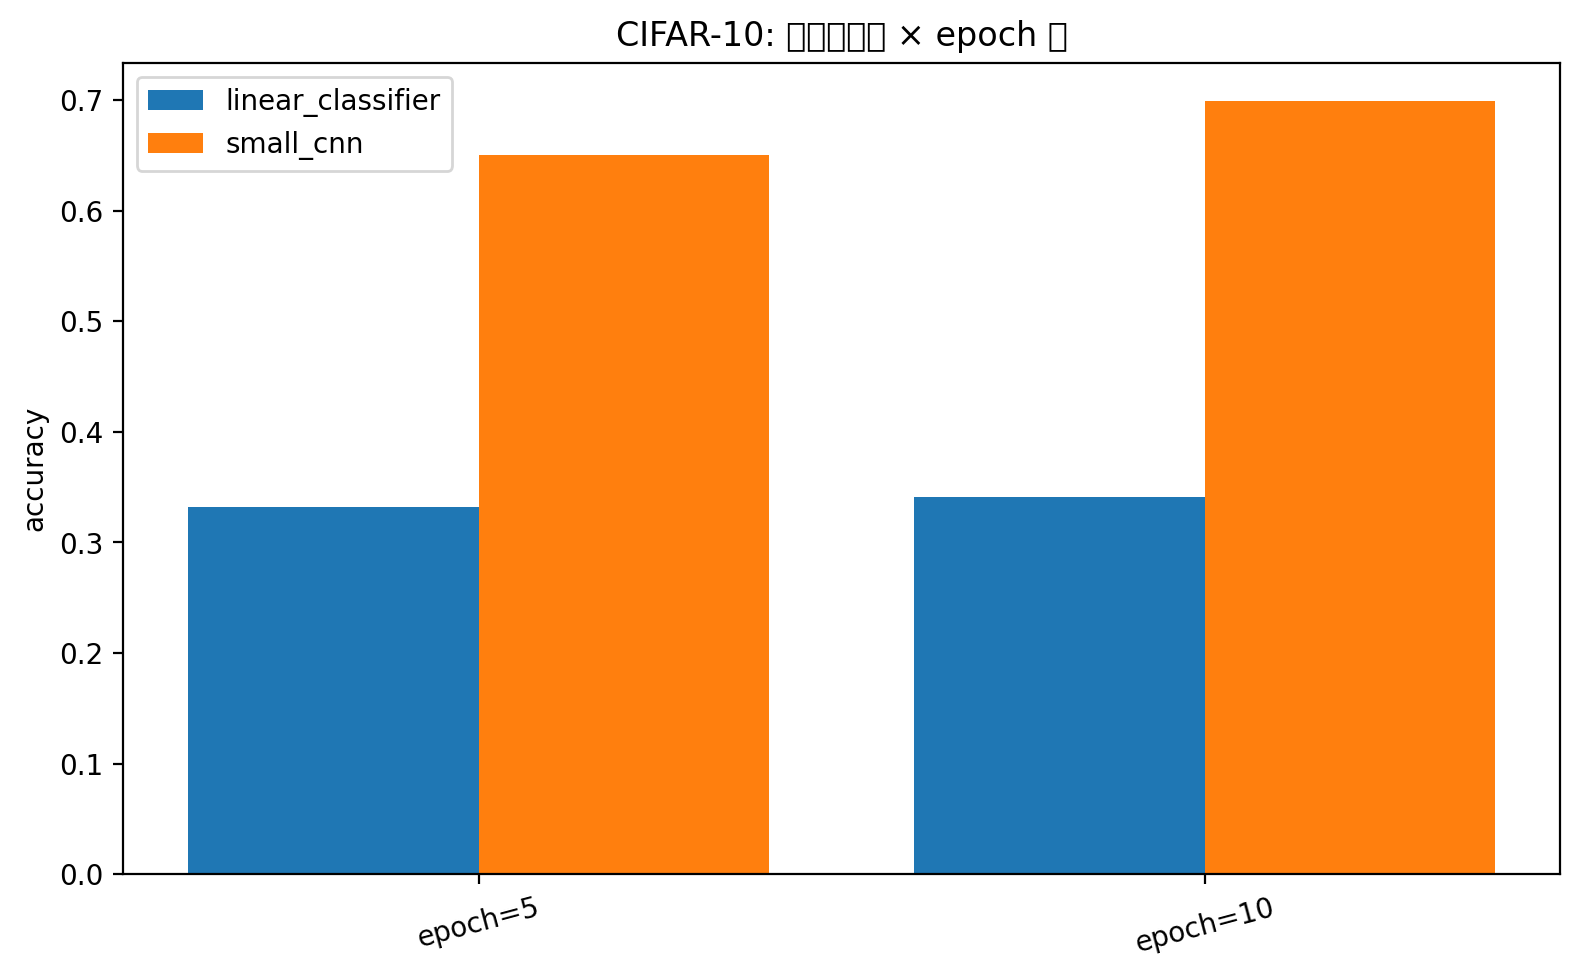

### cnn_vs_linear_runtime.png

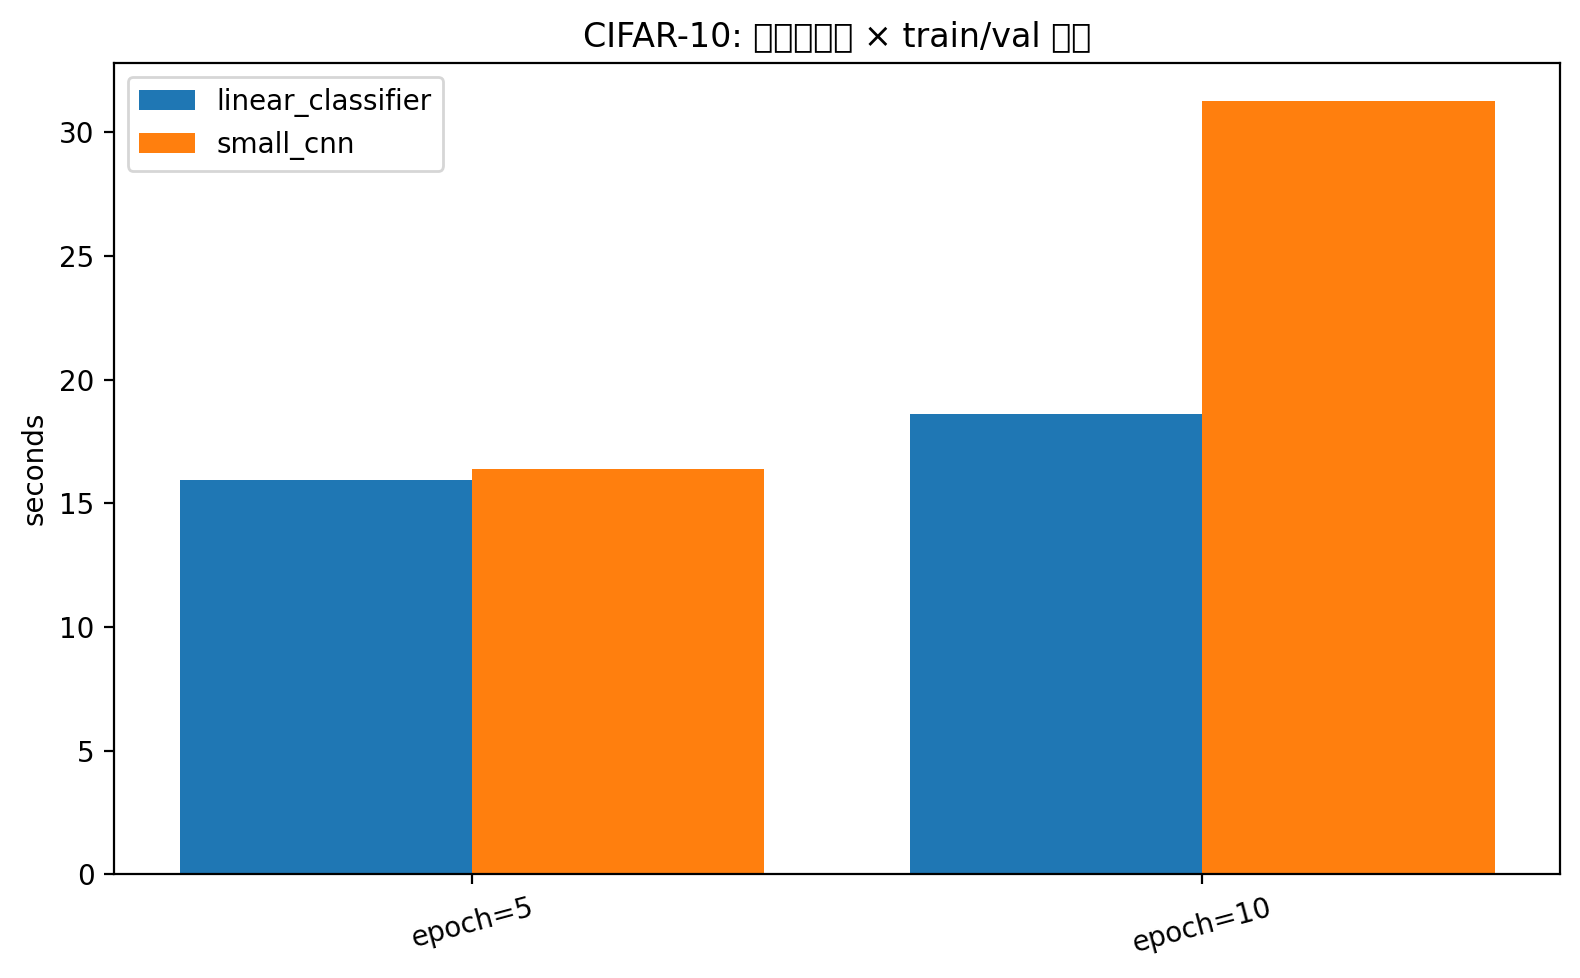

### linear_classifier_e10_training_curves.png

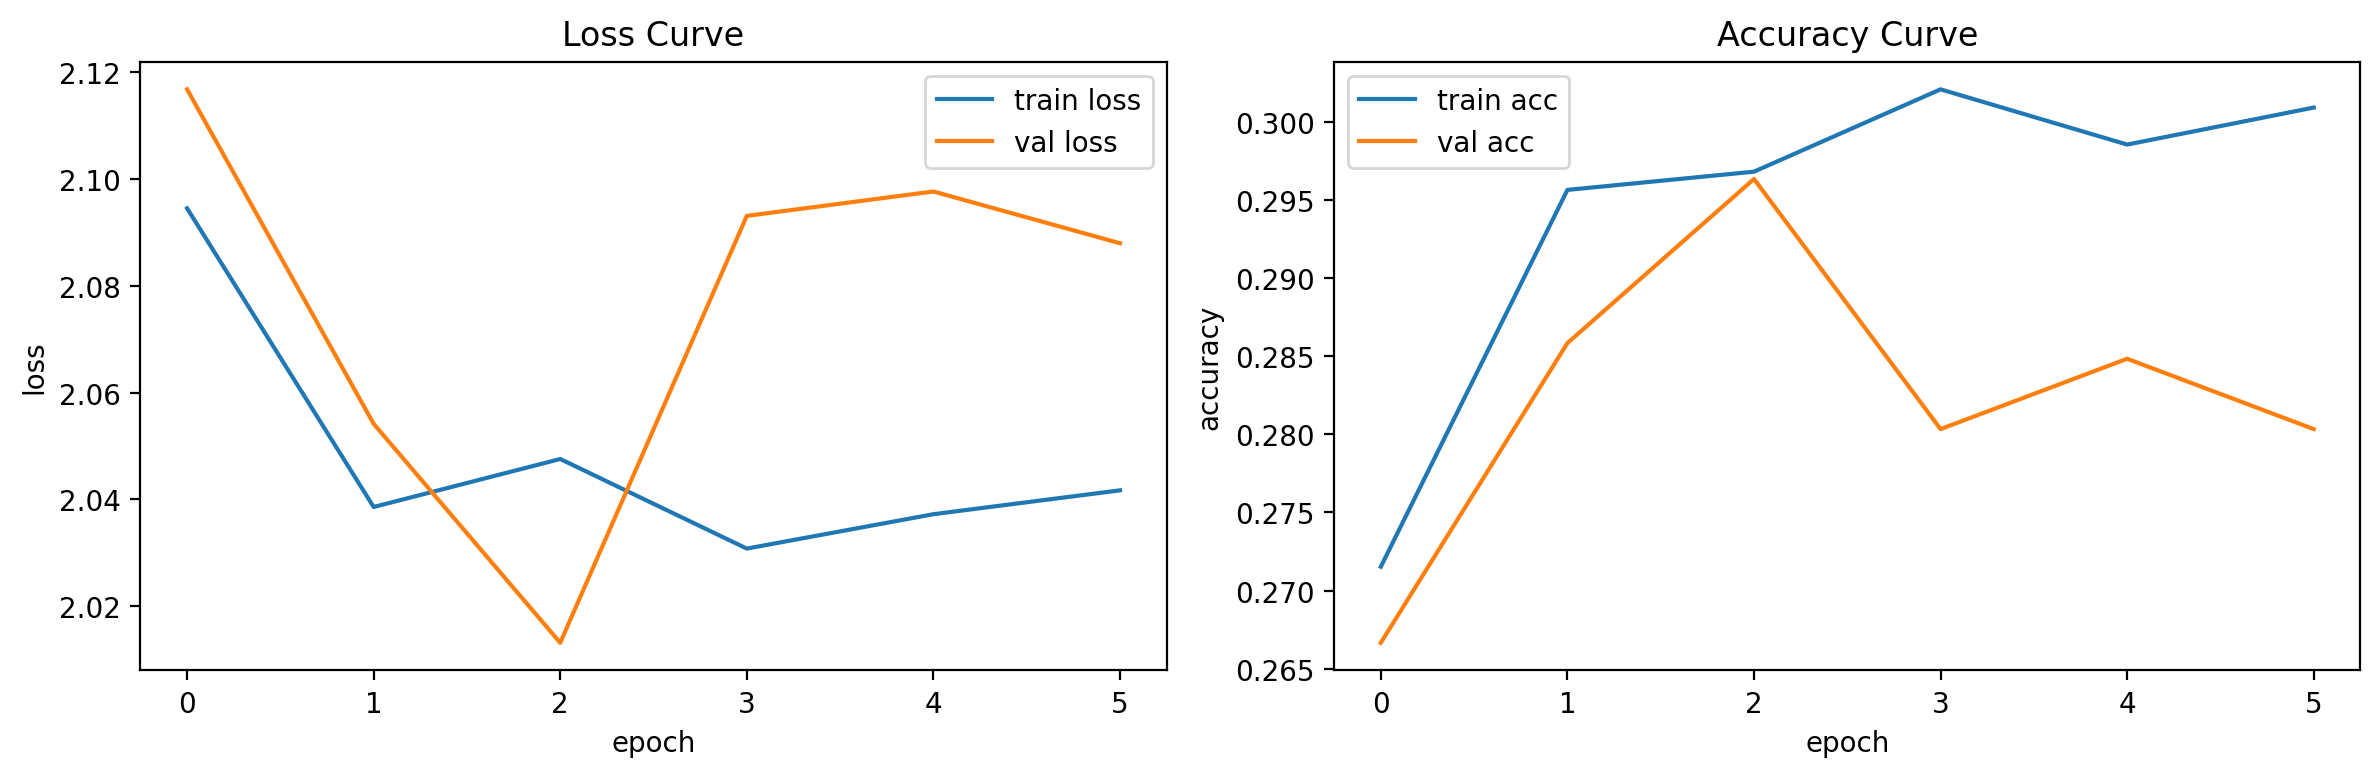

### linear_classifier_e5_training_curves.png

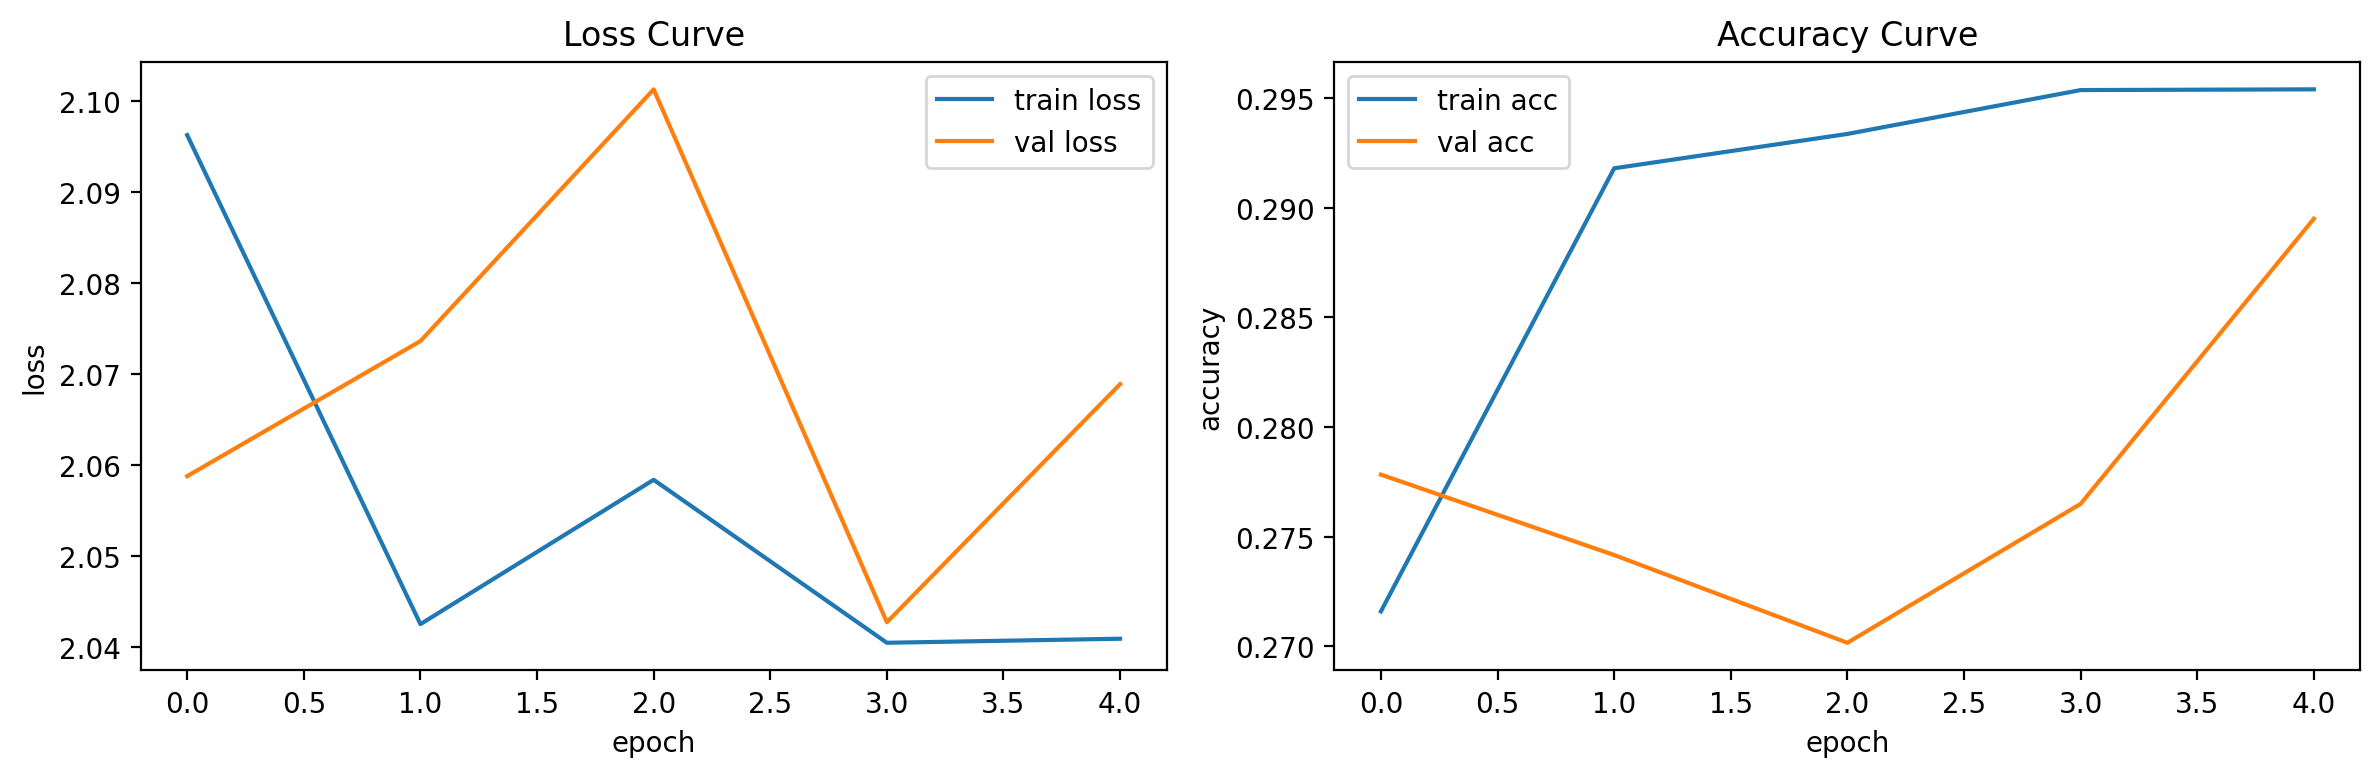

### linear_classifier_training_curves.png

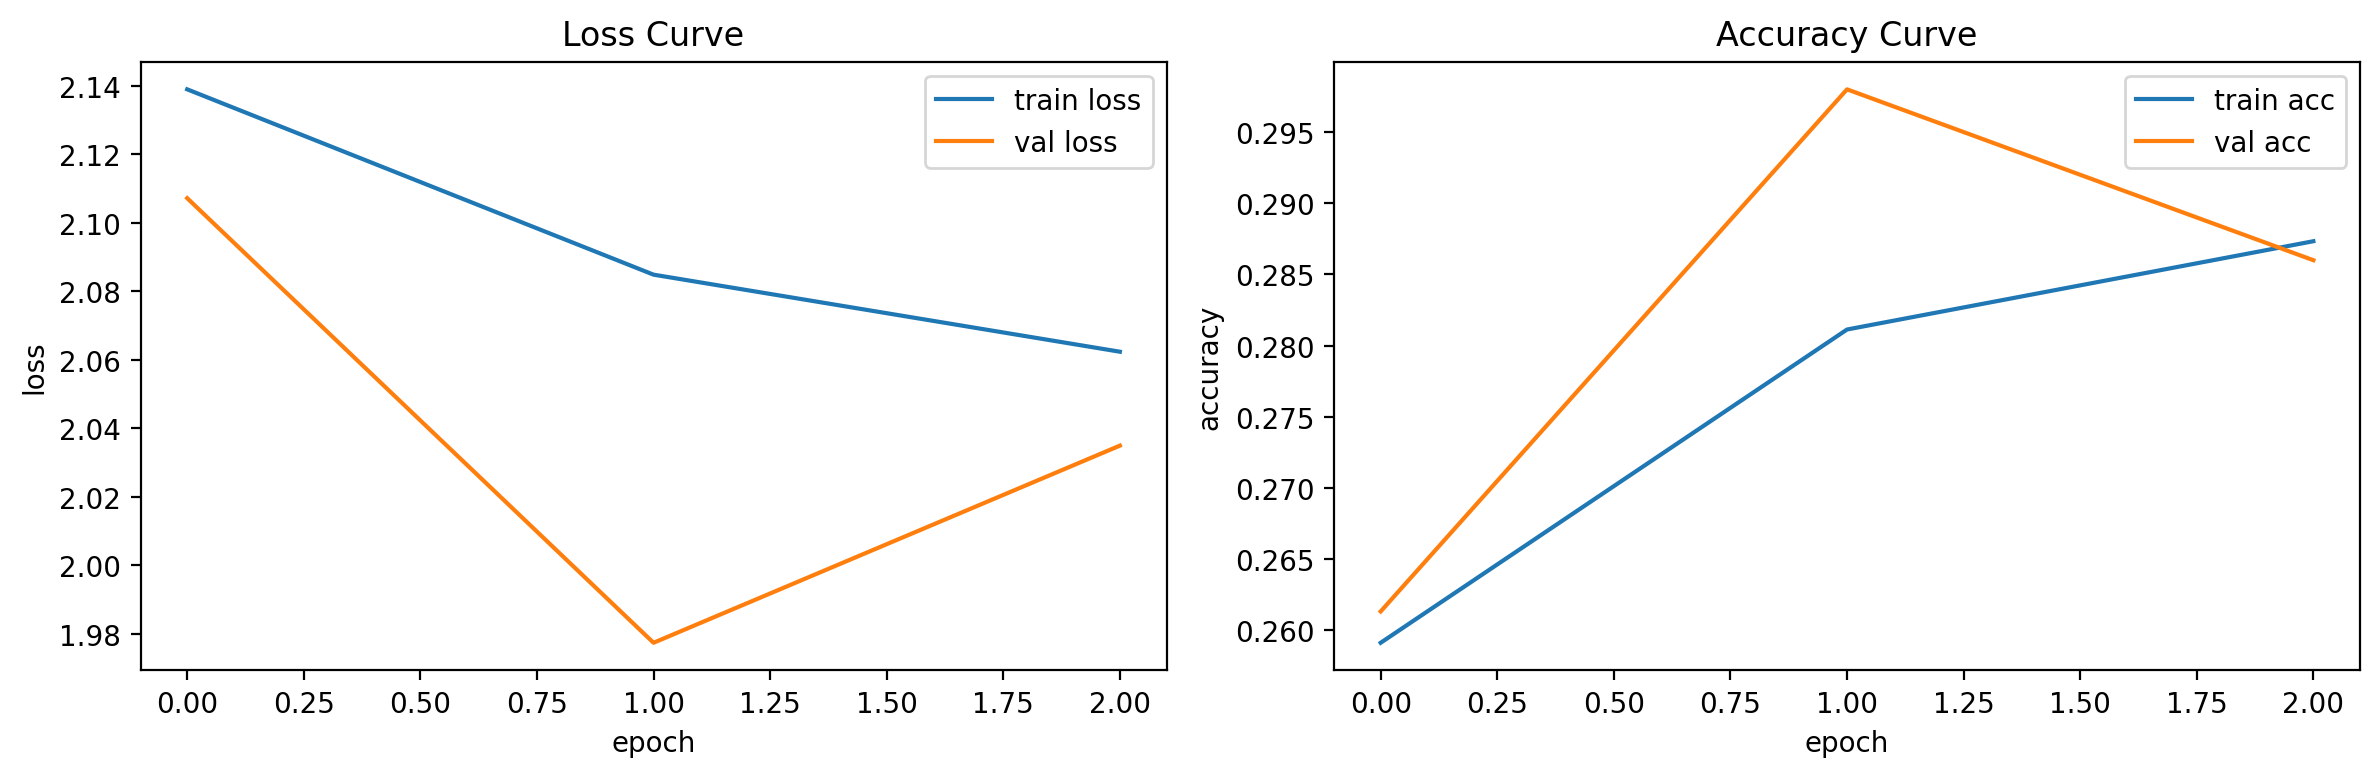

### residual_cnn_e10_training_curves.png

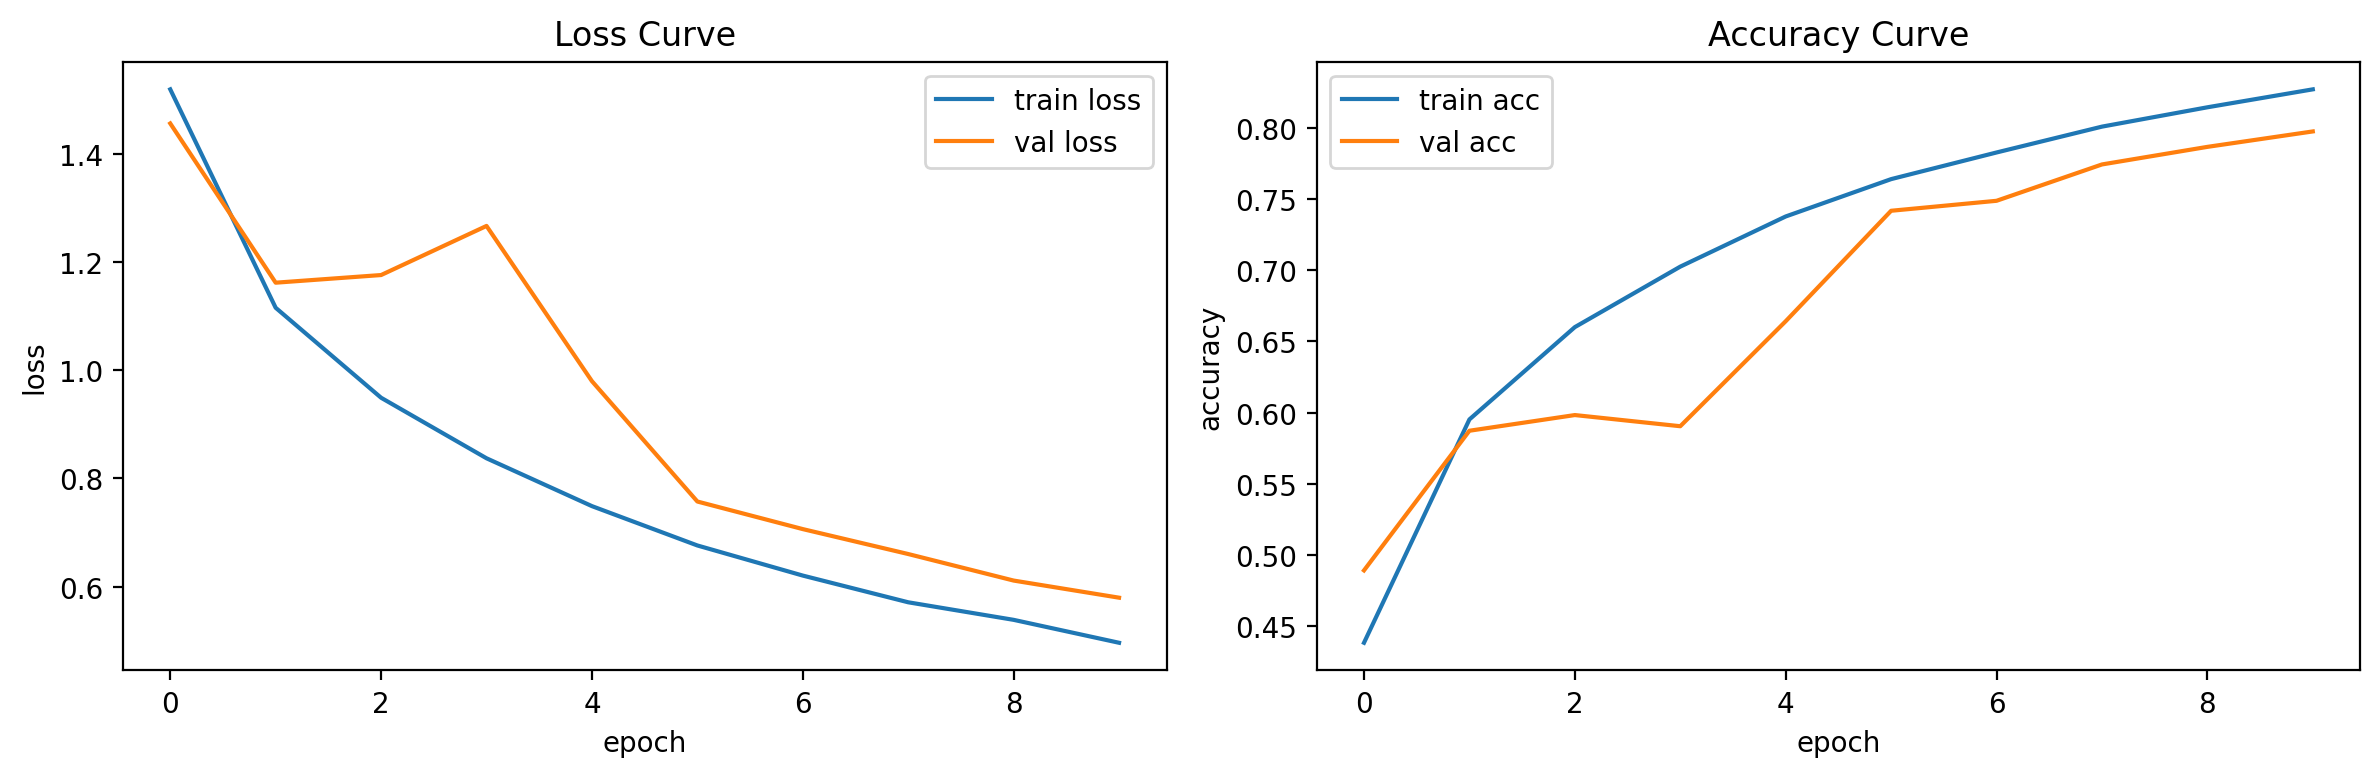

### residual_cnn_extra_comparison.png

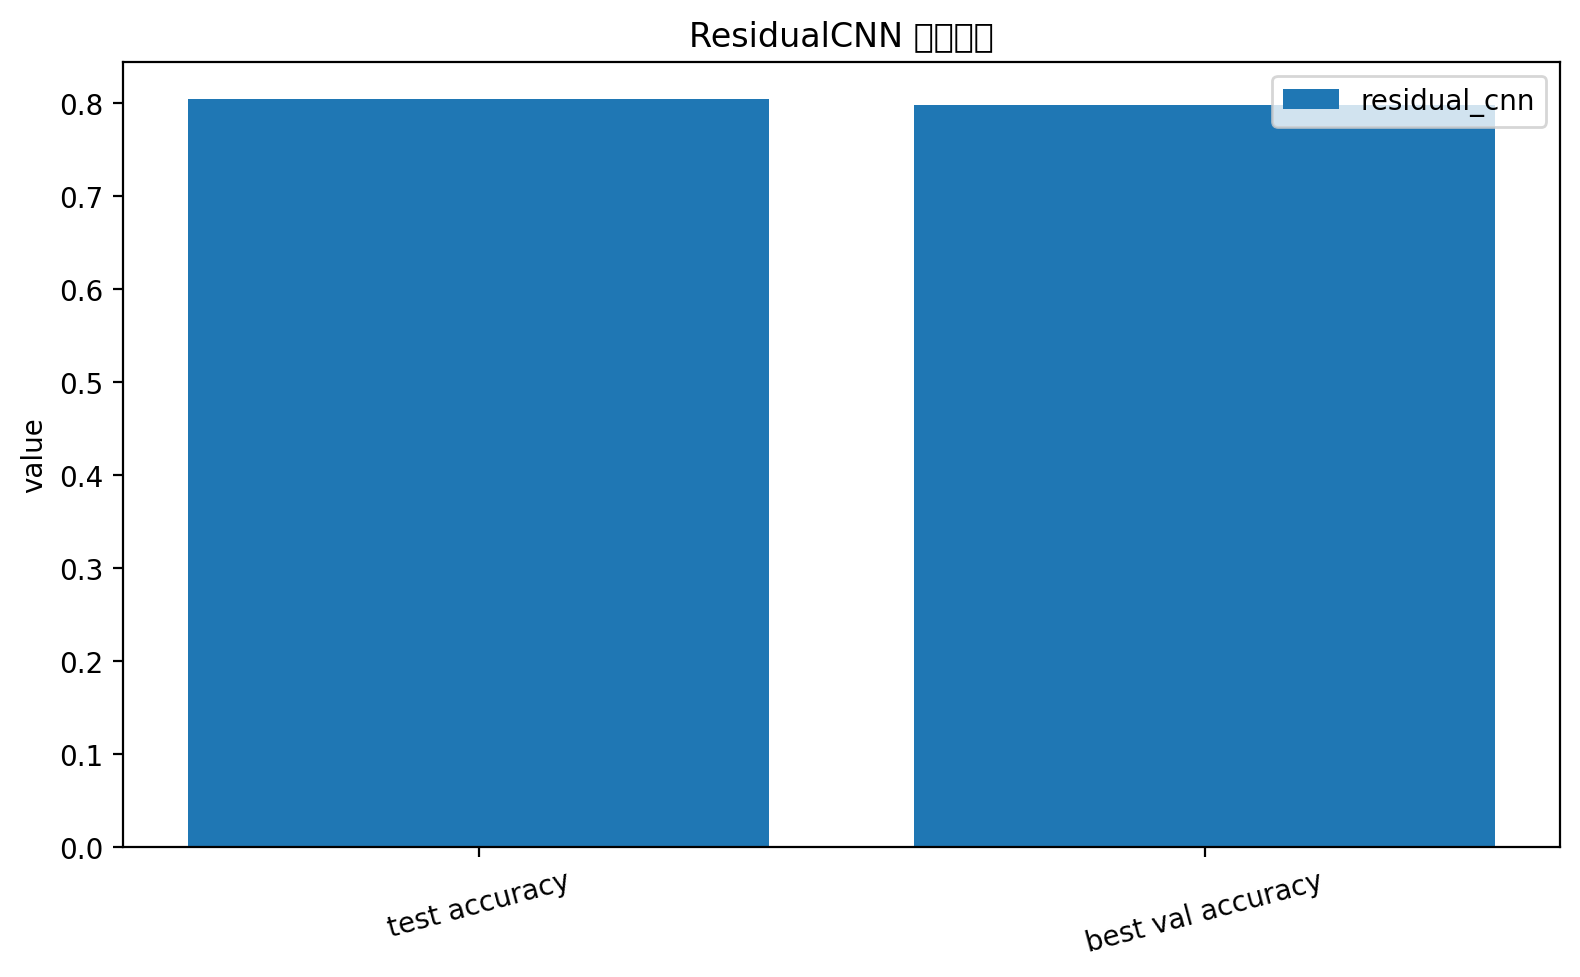

### small_cnn_e10_training_curves.png

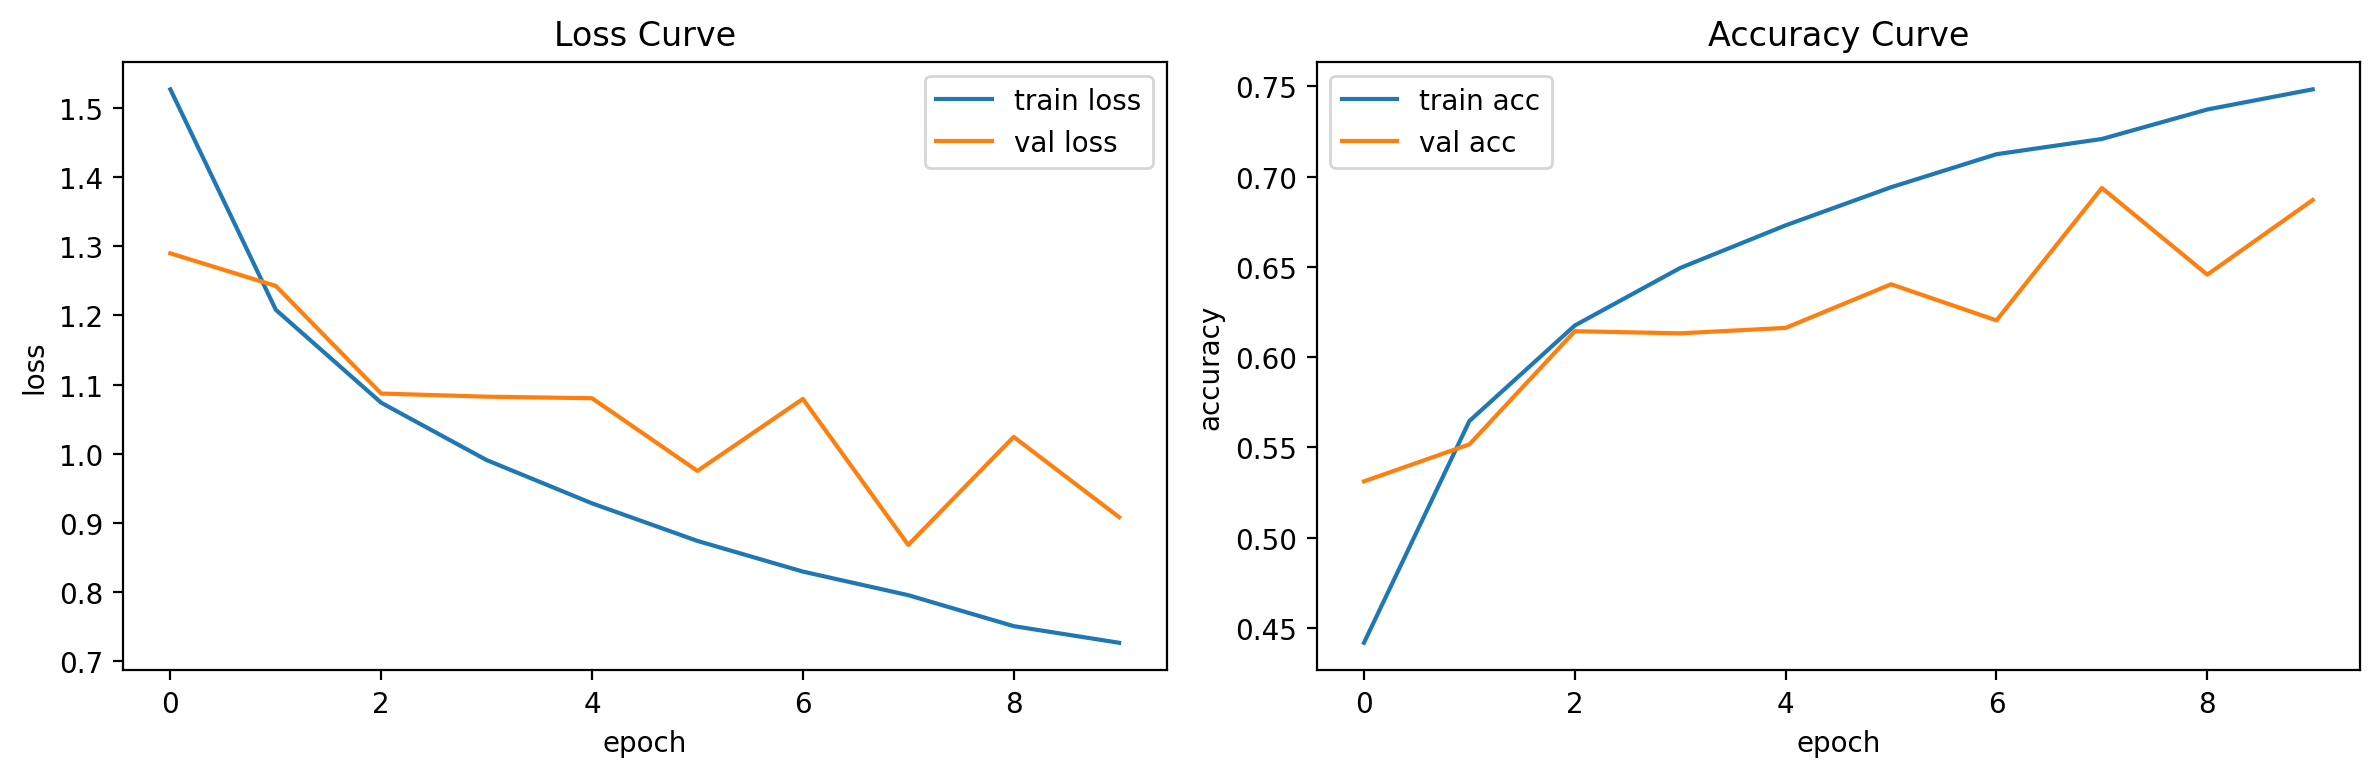

### small_cnn_e5_training_curves.png

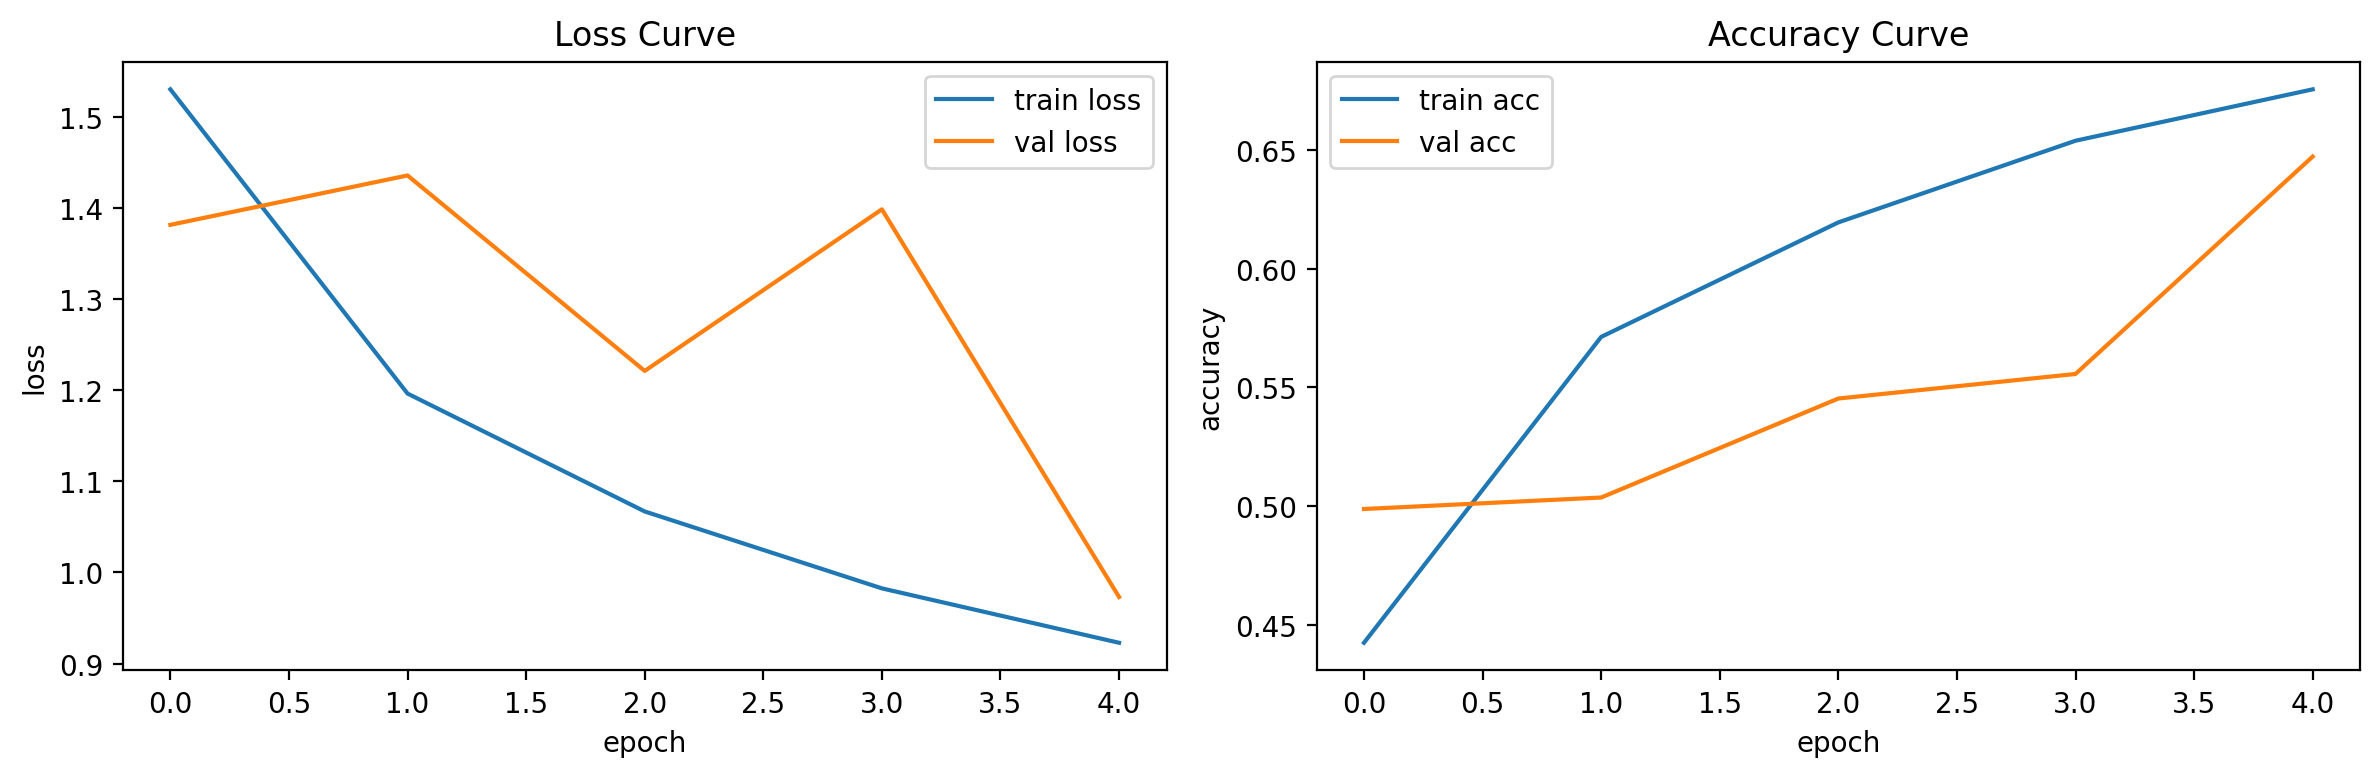

### small_cnn_training_curves.png

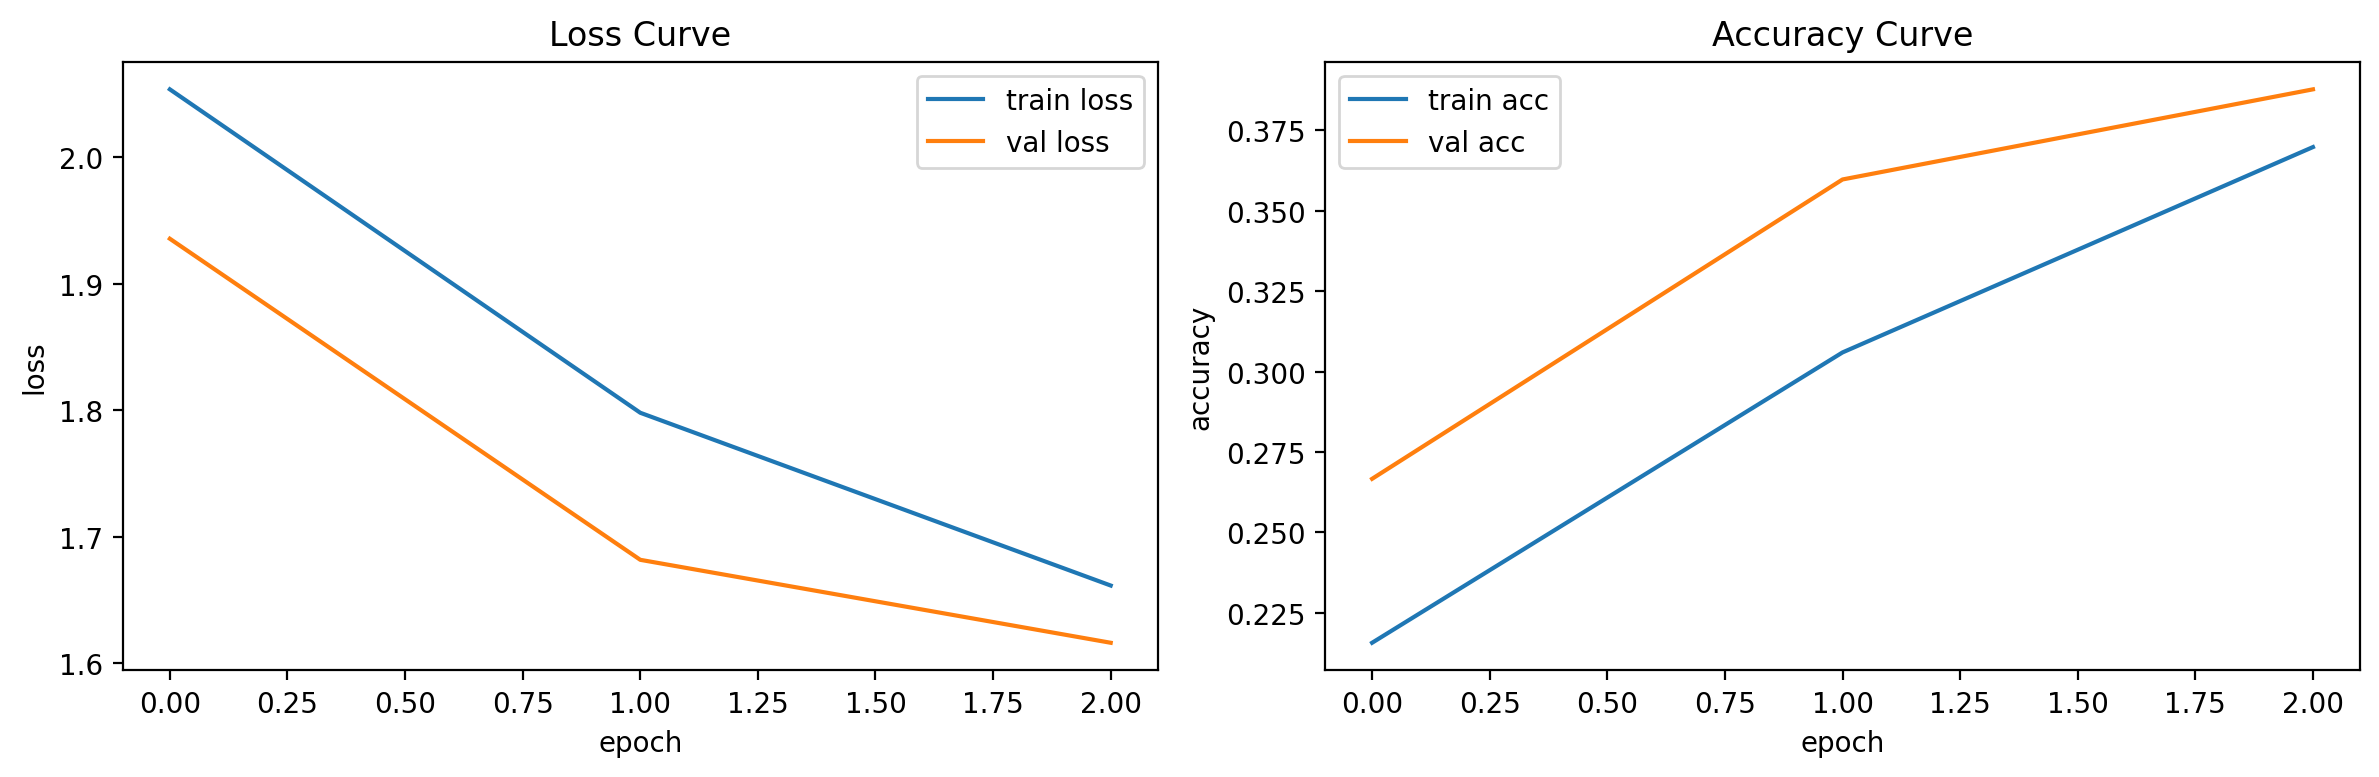

In [5]:
from pathlib import Path
import json
from IPython.display import Image, Video, display, Markdown

out_dir = None
for candidate in [Path('/content/drive/MyDrive/learning_guide_outputs/01_cnn_cifar10'), Path('/content/learning_guide_outputs/01_cnn_cifar10')]:
    if candidate.exists():
        out_dir = candidate
        break

if out_dir is None:
    print('出力ディレクトリが見つかりませんでした。先に上の実験セルを実行してください。')
else:
    print(f'output_dir = {out_dir}')
    summary_path = out_dir / 'summary.txt'
    metrics_path = out_dir / 'metrics.json'
    if summary_path.exists():
        print('\n===== summary.txt =====\n')
        print(summary_path.read_text(encoding='utf-8'))
    if metrics_path.exists():
        print('\n===== metrics.json (先頭 1500 文字) =====\n')
        text = metrics_path.read_text(encoding='utf-8')
        print(text[:1500] + ('...' if len(text) > 1500 else ''))
    png_paths = sorted(out_dir.glob('*.png'))
    for png in png_paths:
        display(Markdown(f'### {png.name}'))
        display(Image(filename=str(png)))
    mp4_paths = sorted(out_dir.glob('*.mp4'))
    for mp4 in mp4_paths:
        display(Markdown(f'### {mp4.name}'))
        display(Video(str(mp4), embed=True, width=720))
